# EDA 노트북

- **읽기:** `binfo1-work/` (원본 데이터)
- **쓰기:** `eda-output/` (이 노트북에서 새로 만드는 파일)

> 먼저 **Cell 1 (경로 설정)** 을 실행하세요.

In [21]:
from pathlib import Path

# 원본 실습 데이터 (읽기만)
INPUT_DIR = Path('binfo1-work')

# EDA에서 새로 만드는 파일/결과 저장 위치
OUTPUT_DIR = Path('eda-output')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)

print(f'[Input]  {INPUT_DIR.resolve()}')
print(f'[Output] {OUTPUT_DIR.resolve()}')

[Input]  /home/ssy010622/bioinfo1_project/binfo1-work
[Output] /home/ssy010622/bioinfo1_project/eda-output


# LIN28A 프로젝트 EDA

목표:
- read count 파일 구조를 확인한다.
- CLIP-seq, RNA-seq, RPF-seq count를 하나의 gene-level table로 합칠 준비를 한다.
- 이후 LIN28A binding과 translation change의 관계를 분석한다.

오늘 할 일:
1. 현재 폴더 확인
2. 파일 목록 확인
3. read_counts_multimap.txt 구조 확인
4. read_counts_multimap.txt.summary 확인

In [22]:
with open("binfo1-work/read-counts_multimap.txt", "r") as f:
    for i in range(15):
        line = f.readline()
        print(line.rstrip())

# Program:multimap_read_counter (fractional counts; multi-mapping via NH tag)
# Command:python multimap_read_counter.py --output read-counts_multimap.txt ...
Geneid	Chr	Start	End	Strand	Length	CLIP-35L33G.bam	CLIP-let7g.bam	RNA-control.bam	RNA-siLin28a.bam	RNA-siLuc.bam	RPF-siLin28a.bam	RPF-siLuc.bam
ENSMUSG00000102693.2	chr1	3143476	3144545	+	1070	0.02631578947368421	0.0	2.0	0.0	0.0	0.0	0.0
ENSMUSG00000064842.3	chr1	3172239	3172348	+	110	0.0	0.0	0.0	0.0	0.0	0.0	0.0
ENSMUSG00000051951.6	chr1;chr1;chr1;chr1;chr1;chr1;chr1	3276124;3276746;3283662;3283832;3284705;3491925;3740775	3277540;3277540;3285855;3286567;3287191;3492124;3741721	-;-;-;-;-;-;-	6094	4.0233333333333325	0.0	53.5	1.0	1.0	0.0	0.0
ENSMUSG00000102851.2	chr1	3322980	3323459	+	480	3.0	0.0	0.0	0.0	0.0	0.0	0.0
ENSMUSG00000103377.2	chr1	3435954	3438772	-	2819	0.016666666666666666	0.0	0.041666666666666664	0.0	0.2	0.0	0.0
ENSMUSG00000104017.2	chr1	3445779	3448011	-	2233	0.016666666666666666	0.0	0.041666666666666664	0.0	0.0	0.0	0.0


In [23]:
counts_raw = pd.read_csv("binfo1-work/read-counts_multimap.txt", sep="\t", comment="#")

print("행 개수, 열 개수:")
print(counts_raw.shape)

print("\n열 이름:")
print(counts_raw.columns.tolist())

counts_raw.head()

행 개수, 열 개수:
(55359, 13)

열 이름:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'CLIP-35L33G.bam', 'CLIP-let7g.bam', 'RNA-control.bam', 'RNA-siLin28a.bam', 'RNA-siLuc.bam', 'RPF-siLin28a.bam', 'RPF-siLuc.bam']


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,CLIP-let7g.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0.026316,0.0,2.000000,0.0,0.0,0.0,0.0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4.023333,0.0,53.500000,1.0,1.0,0.0,0.0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0.016667,0.0,0.041667,0.0,0.2,0.0,0.0


In [24]:
# featureCounts 기본 annotation column 후보
meta_cols = ["Geneid", "Chr", "Start", "End", "Strand", "Length"]

# 실제 파일에 존재하는 meta column만 골라내기
meta_cols_present = [c for c in meta_cols if c in counts_raw.columns]

# meta column이 아닌 나머지를 sample count column으로 간주
sample_cols = [c for c in counts_raw.columns if c not in meta_cols_present]

print("meta columns:")
print(meta_cols_present)

print("\nsample columns:")
for c in sample_cols:
    print(c)

meta columns:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']

sample columns:
CLIP-35L33G.bam
CLIP-let7g.bam
RNA-control.bam
RNA-siLin28a.bam
RNA-siLuc.bam
RPF-siLin28a.bam
RPF-siLuc.bam


In [25]:
rename_map = {}

for c in sample_cols:
    # 경로가 들어있을 수도 있으니 파일 이름만 남김
    clean = Path(c).name
    
    # 확장자 제거
    clean = clean.replace(".bam", "")
    
    rename_map[c] = clean

counts = counts_raw.rename(columns=rename_map)

sample_cols_clean = [rename_map[c] for c in sample_cols]

print("정리된 sample columns:")
for c in sample_cols_clean:
    print(c)

counts.head()

정리된 sample columns:
CLIP-35L33G
CLIP-let7g
RNA-control
RNA-siLin28a
RNA-siLuc
RPF-siLin28a
RPF-siLuc


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,CLIP-let7g,RNA-control,RNA-siLin28a,RNA-siLuc,RPF-siLin28a,RPF-siLuc
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0.026316,0.0,2.000000,0.0,0.0,0.0,0.0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4.023333,0.0,53.500000,1.0,1.0,0.0,0.0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0.016667,0.0,0.041667,0.0,0.2,0.0,0.0


## Step 2. Gene-level master table 만들기

이 단계의 목표:
- read count table을 다시 불러온다.
- sample 이름을 정리한다.
- 각 sample의 library size를 확인한다.
- CPM으로 normalization한다.
- RNA 변화, RPF 변화, translation efficiency 변화를 계산한다.

주요 계산:
- log2FC_RNA = log2(RNA-siLin28a / RNA-siLuc)
- log2FC_RPF = log2(RPF-siLin28a / RPF-siLuc)
- delta_TE = log2FC_RPF - log2FC_RNA
- CLIP_enrichment = log2(CLIP-35L33G / RNA-control)

In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 네가 알려준 프로젝트 폴더 경로
DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

print("DATA_DIR:", DATA_DIR)
print("exists:", DATA_DIR.exists())

DATA_DIR: /home/ssy010622/bioinfo1_project/binfo1-work
exists: True


In [27]:
count_file = DATA_DIR / "read-counts_multimap.txt"

print("count_file:", count_file)
print("exists:", count_file.exists())

count_file: /home/ssy010622/bioinfo1_project/binfo1-work/read-counts_multimap.txt
exists: True


In [28]:
count_file = DATA_DIR / "read-counts_multimap.txt"

summary_candidates = sorted(DATA_DIR.glob("*multimap*.summary"))


In [29]:
counts_raw = pd.read_csv(count_file, sep="\t", comment="#")

print("raw shape:", counts_raw.shape)
print("raw columns:")
print(counts_raw.columns.tolist())

counts = counts_raw.copy()

# sample column 이름에서 .bam 제거
rename_map = {}
for c in counts.columns:
    clean = Path(c).name
    clean = clean.replace(".bam", "")
    rename_map[c] = clean

counts = counts.rename(columns=rename_map)

print("\ncleaned columns:")
print(counts.columns.tolist())

counts.head()

raw shape: (55359, 13)
raw columns:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'CLIP-35L33G.bam', 'CLIP-let7g.bam', 'RNA-control.bam', 'RNA-siLin28a.bam', 'RNA-siLuc.bam', 'RPF-siLin28a.bam', 'RPF-siLuc.bam']

cleaned columns:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'CLIP-35L33G', 'CLIP-let7g', 'RNA-control', 'RNA-siLin28a', 'RNA-siLuc', 'RPF-siLin28a', 'RPF-siLuc']


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,CLIP-let7g,RNA-control,RNA-siLin28a,RNA-siLuc,RPF-siLin28a,RPF-siLuc
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0.026316,0.0,2.000000,0.0,0.0,0.0,0.0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4.023333,0.0,53.500000,1.0,1.0,0.0,0.0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0.016667,0.0,0.041667,0.0,0.2,0.0,0.0


In [30]:
main_samples = [
    "CLIP-35L33G",
    "RNA-control",
    "RNA-siLin28a",
    "RNA-siLuc",
    "RPF-siLin28a",
    "RPF-siLuc"
]

# 혹시 빠진 column이 있는지 확인
missing = [s for s in main_samples if s not in counts.columns]

if len(missing) == 0:
    print("모든 main sample column이 존재합니다.")
else:
    print("빠진 sample column:", missing)

모든 main sample column이 존재합니다.


In [31]:
# count column을 숫자형으로 변환
for s in main_samples:
    counts[s] = pd.to_numeric(counts[s], errors="coerce").fillna(0)

# sample별 assigned count 총합 계산
library_size = counts[main_samples].sum()

library_table = pd.DataFrame({
    "sample": library_size.index,
    "assigned_count": library_size.values,
    "assigned_count_million": library_size.values / 1_000_000
})

library_table

,sample,assigned_count,assigned_count_million
0,CLIP-35L33G,1.491820e+07,14.918195
1,RNA-control,5.920240e+06,5.920240
2,RNA-siLin28a,1.376943e+07,13.769431
3,RNA-siLuc,1.085953e+07,10.859527
4,RPF-siLin28a,1.241163e+07,12.411633
5,RPF-siLuc,1.475418e+07,14.754185


In [32]:
if len(summary_candidates) > 0:
    summary_file = summary_candidates[0]
    print("사용할 summary file:", summary_file.name)

    summary = pd.read_csv(summary_file, sep="\t", index_col=0)

    print("summary shape:", summary.shape)
    display(summary.head())

    if "Assigned" in summary.columns:
        summary_assigned = summary["Assigned"].copy()
        summary_assigned.index = summary_assigned.index.str.replace(".bam", "", regex=False)

        compare_library = pd.concat(
            [
                library_size.rename("sum_from_count_table"),
                summary_assigned.rename("assigned_from_summary")
            ],
            axis=1
        )

        compare_library["difference"] = (
            compare_library["sum_from_count_table"] 
            - compare_library["assigned_from_summary"]
        )

        display(compare_library)
else:
    print("summary 파일을 찾지 못했습니다.")

사용할 summary file: read-counts_multimap.txt.summary
summary shape: (7, 1)


,Assigned
CLIP-35L33G.bam,1.491820e+07
CLIP-let7g.bam,1.630000e+02
RNA-control.bam,5.920240e+06
RNA-siLin28a.bam,1.376943e+07
RNA-siLuc.bam,1.085953e+07


,sum_from_count_table,assigned_from_summary,difference
CLIP-35L33G,1.491820e+07,1.491820e+07,0.000000e+00
RNA-control,5.920240e+06,5.920240e+06,0.000000e+00
RNA-siLin28a,1.376943e+07,1.376943e+07,-1.862645e-09
RNA-siLuc,1.085953e+07,1.085953e+07,-1.862645e-09
RPF-siLin28a,1.241163e+07,1.241163e+07,0.000000e+00
RPF-siLuc,1.475418e+07,1.475418e+07,0.000000e+00
CLIP-let7g,NaN,1.630000e+02,NaN


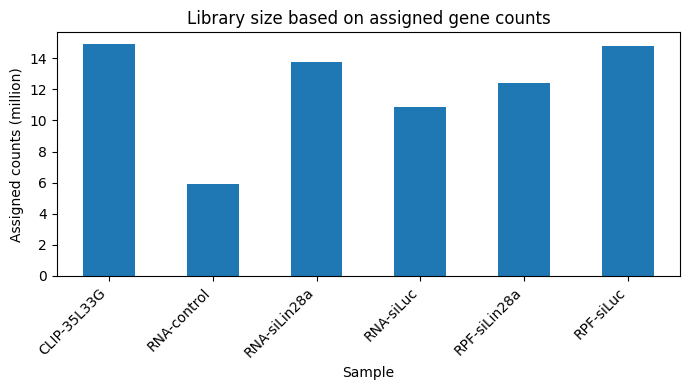

In [33]:
# QC 용 

library_table_plot = library_table.set_index("sample")

plt.figure(figsize=(7, 4))
library_table_plot["assigned_count_million"].plot(kind="bar")

plt.ylabel("Assigned counts (million)")
plt.xlabel("Sample")
plt.title("Library size based on assigned gene counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
meta_cols = ["Geneid", "Chr", "Start", "End", "Strand", "Length"]

master = counts[meta_cols + main_samples].copy()

# Geneid에서 version 제거한 column도 만들어두기
# 예: ENSMUSG00000000001.4 -> ENSMUSG00000000001
master["gene_id_no_version"] = master["Geneid"].str.replace(r"\.\d+$", "", regex=True)

master.head()

,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,RNA-control,RNA-siLin28a,RNA-siLuc,RPF-siLin28a,RPF-siLuc,gene_id_no_version
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0.026316,2.000000,0.0,0.0,0.0,0.0,ENSMUSG00000102693
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0.000000,0.000000,0.0,0.0,0.0,0.0,ENSMUSG00000064842
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4.023333,53.500000,1.0,1.0,0.0,0.0,ENSMUSG00000051951
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3.000000,0.000000,0.0,0.0,0.0,0.0,ENSMUSG00000102851
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0.016667,0.041667,0.0,0.2,0.0,0.0,ENSMUSG00000103377


In [35]:
for s in main_samples:
    master[f"{s}_CPM"] = master[s] / library_size[s] * 1_000_000

cpm_cols = [f"{s}_CPM" for s in main_samples]

master[["Geneid", "Length"] + cpm_cols].head()

,Geneid,Length,CLIP-35L33G_CPM,RNA-control_CPM,RNA-siLin28a_CPM,RNA-siLuc_CPM,RPF-siLin28a_CPM,RPF-siLuc_CPM
0,ENSMUSG00000102693.2,1070,0.001764,0.337824,0.000000,0.000000,0.0,0.0
1,ENSMUSG00000064842.3,110,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,ENSMUSG00000051951.6,6094,0.269693,9.036795,0.072625,0.092085,0.0,0.0
3,ENSMUSG00000102851.2,480,0.201097,0.000000,0.000000,0.000000,0.0,0.0
4,ENSMUSG00000103377.2,2819,0.001117,0.007038,0.000000,0.018417,0.0,0.0


In [36]:
# log 계산에서 0으로 나누는 것을 막기 위한 작은 값
pseudo_cpm = 0.5

master["log2FC_RNA"] = np.log2(
    (master["RNA-siLin28a_CPM"] + pseudo_cpm) /
    (master["RNA-siLuc_CPM"] + pseudo_cpm)
)

master["log2FC_RPF"] = np.log2(
    (master["RPF-siLin28a_CPM"] + pseudo_cpm) /
    (master["RPF-siLuc_CPM"] + pseudo_cpm)
)

# Translation efficiency 변화
# RPF 변화에서 RNA abundance 변화를 뺀 값
master["delta_TE"] = master["log2FC_RPF"] - master["log2FC_RNA"]

# LIN28A CLIP enrichment
# CLIP signal을 RNA-control abundance로 보정
master["CLIP_enrichment"] = np.log2(
    (master["CLIP-35L33G_CPM"] + pseudo_cpm) /
    (master["RNA-control_CPM"] + pseudo_cpm)
)

master[
    [
        "Geneid",
        "Length",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "CLIP-35L33G_CPM",
        "RNA-control_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].head()

,Geneid,Length,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,CLIP-35L33G_CPM,RNA-control_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
0,ENSMUSG00000102693.2,1070,0.000000,0.000000,0.0,0.0,0.001764,0.337824,0.000000,0.0,0.000000,-0.739638
1,ENSMUSG00000064842.3,110,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,ENSMUSG00000051951.6,6094,0.092085,0.072625,0.0,0.0,0.269693,9.036795,-0.048215,0.0,0.048215,-3.631149
3,ENSMUSG00000102851.2,480,0.000000,0.000000,0.0,0.0,0.201097,0.000000,0.000000,0.0,0.000000,0.487685
4,ENSMUSG00000103377.2,2819,0.018417,0.000000,0.0,0.0,0.001117,0.007038,-0.052185,0.0,0.052185,-0.016946


In [37]:
analysis_df = master[
    (master["RNA-siLuc_CPM"] >= 1) &
    (master["RNA-siLin28a_CPM"] >= 1) &
    ((master["RPF-siLuc"] + master["RPF-siLin28a"]) >= 20)
].copy()

print("전체 gene 수:", len(master))
print("필터 통과 gene 수:", len(analysis_df))

analysis_df[
    [
        "Geneid",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].head()

전체 gene 수: 55359
필터 통과 gene 수: 14408


,Geneid,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
21,ENSMUSG00000102269.2,14.641522,21.642144,7.421623,4.632750,0.548285,-0.626064,-1.174349,-2.697591
26,ENSMUSG00000098104.2,10.232951,11.039025,6.811627,2.779650,0.104475,-1.156650,-1.261125,-0.446509
30,ENSMUSG00000103922.2,40.839718,37.764815,37.085524,35.276045,-0.111510,-0.071183,0.040327,0.217960
31,ENSMUSG00000033845.14,242.582739,223.014521,219.894869,151.690037,-0.121079,-0.534217,-0.413138,0.217021
32,ENSMUSG00000102275.2,5.157372,6.899341,2.758818,1.813404,0.387265,-0.494331,-0.881596,-0.133020


In [38]:
analysis_df[
    [
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].describe()

,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
count,14408.000000,14408.000000,14408.000000,14408.000000,14408.000000,14408.000000,14408.000000,14408.000000
mean,68.309192,68.328651,67.508828,67.655457,0.045549,-0.176169,-0.221718,-0.611991
std,247.188351,210.222434,3288.649685,3437.416461,0.430793,0.597818,0.596264,1.293496
min,1.005262,1.004641,0.271110,0.000000,-2.638118,-2.166024,-2.299742,-6.543572
25%,7.573995,8.061335,3.585572,3.222783,-0.224129,-0.579987,-0.636613,-1.433270
50%,24.444743,25.273376,11.050248,9.497138,0.022541,-0.215797,-0.237713,-0.609395
75%,67.257383,67.867946,32.872030,27.715933,0.292207,0.211651,0.183785,0.216965
max,22491.350453,16039.158596,394049.981519,411007.341539,2.372380,2.557197,3.211019,7.065669


In [39]:
master_out = DATA_DIR / "01_master_gene_table.tsv"
analysis_out = DATA_DIR / "01_analysis_gene_table_filtered.tsv"

master.to_csv(master_out, sep="\t", index=False)
analysis_df.to_csv(analysis_out, sep="\t", index=False)

print("저장 완료:")
print(master_out)
print(analysis_out)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/01_master_gene_table.tsv
/home/ssy010622/bioinfo1_project/binfo1-work/01_analysis_gene_table_filtered.tsv


## Step 3. Gene annotation 추가와 outlier 확인

이 단계의 목표:
- gencode.gtf에서 gene_name과 gene_type을 가져온다.
- master table에 annotation을 붙인다.
- RPF count가 매우 높은 gene들이 무엇인지 확인한다.
- protein-coding gene만 남긴 분석용 table을 만든다.

In [40]:
#3-1. gencode.gtf 파일 읽기
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

gtf_file = DATA_DIR / "gencode.gtf"

print("gtf_file:", gtf_file)
print("exists:", gtf_file.exists())

gtf_file: /home/ssy010622/bioinfo1_project/binfo1-work/gencode.gtf
exists: True


In [41]:
with open(gtf_file, "r") as f:
    for i in range(10):
        print(f.readline().rstrip())

##description: evidence-based annotation of the mouse genome (GRCm39), version M27 (Ensembl 104)
##provider: GENCODE
##contact: gencode-help@ebi.ac.uk
##format: gtf
##date: 2021-03-04
chr1	HAVANA	gene	3143476	3144545	.	+	.	gene_id "ENSMUSG00000102693.2"; gene_type "TEC"; gene_name "4933401J01Rik"; level 2; mgi_id "MGI:1918292"; havana_gene "OTTMUSG00000049935.1";
chr1	HAVANA	transcript	3143476	3144545	.	+	.	gene_id "ENSMUSG00000102693.2"; transcript_id "ENSMUST00000193812.2"; gene_type "TEC"; gene_name "4933401J01Rik"; transcript_type "TEC"; transcript_name "4933401J01Rik-201"; level 2; transcript_support_level "NA"; mgi_id "MGI:1918292"; tag "basic"; havana_gene "OTTMUSG00000049935.1"; havana_transcript "OTTMUST00000127109.1";
chr1	HAVANA	exon	3143476	3144545	.	+	.	gene_id "ENSMUSG00000102693.2"; transcript_id "ENSMUST00000193812.2"; gene_type "TEC"; gene_name "4933401J01Rik"; transcript_type "TEC"; transcript_name "4933401J01Rik-201"; exon_number 1; exon_id "ENSMUSE00001343744.2"; le

In [42]:
gtf_cols = [
    "seqname",
    "source",
    "feature",
    "start",
    "end",
    "score",
    "strand",
    "frame",
    "attribute"
]

gtf = pd.read_csv(
    gtf_file,
    sep="\t",
    comment="#",
    names=gtf_cols,
    low_memory=False
)

print("GTF 전체 행/열:", gtf.shape)

# gene feature만 사용
genes = gtf[gtf["feature"] == "gene"].copy()

print("gene feature 개수:", genes.shape)

# attribute에서 필요한 정보 추출
genes["gene_id"] = genes["attribute"].str.extract(r'gene_id "([^"]+)"')
genes["gene_name"] = genes["attribute"].str.extract(r'gene_name "([^"]+)"')

# GENCODE 버전에 따라 gene_type 또는 gene_biotype일 수 있음
genes["gene_type"] = genes["attribute"].str.extract(r'gene_type "([^"]+)"')

if genes["gene_type"].isna().all():
    genes["gene_type"] = genes["attribute"].str.extract(r'gene_biotype "([^"]+)"')

# version 제거한 gene_id도 만들기
genes["gene_id_no_version"] = genes["gene_id"].str.replace(r"\.\d+$", "", regex=True)

gene_annot = genes[
    [
        "gene_id",
        "gene_id_no_version",
        "gene_name",
        "gene_type",
        "seqname",
        "start",
        "end",
        "strand"
    ]
].copy()

gene_annot.head()

GTF 전체 행/열: (1869107, 9)
gene feature 개수: (55359, 9)


,gene_id,gene_id_no_version,gene_name,gene_type,seqname,start,end,strand
0,ENSMUSG00000102693.2,ENSMUSG00000102693,4933401J01Rik,TEC,chr1,3143476,3144545,+
3,ENSMUSG00000064842.3,ENSMUSG00000064842,Gm26206,snRNA,chr1,3172239,3172348,+
6,ENSMUSG00000051951.6,ENSMUSG00000051951,Xkr4,protein_coding,chr1,3276124,3741721,-
24,ENSMUSG00000102851.2,ENSMUSG00000102851,Gm18956,processed_pseudogene,chr1,3322980,3323459,+
27,ENSMUSG00000103377.2,ENSMUSG00000103377,Gm37180,TEC,chr1,3435954,3438772,-


In [43]:
#3-4
gene_type_counts = gene_annot["gene_type"].value_counts().head(30)

gene_type_counts

gene_type
protein_coding                        21834
processed_pseudogene                   9999
lncRNA                                 9950
TEC                                    3238
unprocessed_pseudogene                 2719
miRNA                                  2201
snoRNA                                 1507
snRNA                                  1381
misc_RNA                                562
rRNA                                    354
transcribed_processed_pseudogene        300
transcribed_unprocessed_pseudogene      272
IG_V_gene                               218
IG_V_pseudogene                         158
TR_V_gene                               144
polymorphic_pseudogene                   89
TR_J_gene                                70
pseudogene                               62
unitary_pseudogene                       61
scaRNA                                   51
TR_V_pseudogene                          34
transcribed_unitary_pseudogene           26
ribozyme              

In [44]:
master_file = DATA_DIR / "01_master_gene_table.tsv"

master = pd.read_csv(master_file, sep="\t")

print("master shape:", master.shape)
master.head()

master shape: (55359, 23)


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,RNA-control,RNA-siLin28a,RNA-siLuc,...,CLIP-35L33G_CPM,RNA-control_CPM,RNA-siLin28a_CPM,RNA-siLuc_CPM,RPF-siLin28a_CPM,RPF-siLuc_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0.026316,2.000000,0.0,0.0,...,0.001764,0.337824,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,-0.739638
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4.023333,53.500000,1.0,1.0,...,0.269693,9.036795,0.072625,0.092085,0.0,0.0,-0.048215,0.0,0.048215,-3.631149
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3.000000,0.000000,0.0,0.0,...,0.201097,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.487685
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0.016667,0.041667,0.0,0.2,...,0.001117,0.007038,0.000000,0.018417,0.0,0.0,-0.052185,0.0,0.052185,-0.016946


In [45]:
#3-6
# master에도 version 제거 gene id가 있는지 확인
if "gene_id_no_version" not in master.columns:
    master["gene_id_no_version"] = master["Geneid"].str.replace(r"\.\d+$", "", regex=True)

master_annot = master.merge(
    gene_annot[["gene_id_no_version", "gene_name", "gene_type"]],
    on="gene_id_no_version",
    how="left"
)

print("annotation 붙인 후 shape:", master_annot.shape)

print("gene_name이 없는 행 수:", master_annot["gene_name"].isna().sum())
print("gene_type이 없는 행 수:", master_annot["gene_type"].isna().sum())

master_annot[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "CLIP_enrichment",
        "delta_TE"
    ]
].head()

annotation 붙인 후 shape: (55359, 25)
gene_name이 없는 행 수: 0
gene_type이 없는 행 수: 0


,Geneid,gene_name,gene_type,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,CLIP_enrichment,delta_TE
0,ENSMUSG00000102693.2,4933401J01Rik,TEC,0.000000,0.000000,0.0,0.0,-0.739638,0.000000
1,ENSMUSG00000064842.3,Gm26206,snRNA,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2,ENSMUSG00000051951.6,Xkr4,protein_coding,0.092085,0.072625,0.0,0.0,-3.631149,0.048215
3,ENSMUSG00000102851.2,Gm18956,processed_pseudogene,0.000000,0.000000,0.0,0.0,0.487685,0.000000
4,ENSMUSG00000103377.2,Gm37180,TEC,0.018417,0.000000,0.0,0.0,-0.016946,0.052185


In [46]:
#4-1. 아까 rpf cpm 최대값이 너무 컸기 때문에,어떤 gene인지 확인해야함
#평균 rpf/rna/clip 값 만들기
master_annot["avg_RNA_CPM"] = (
    master_annot["RNA-siLuc_CPM"] +
    master_annot["RNA-siLin28a_CPM"]
) / 2

master_annot["avg_RPF_CPM"] = (
    master_annot["RPF-siLuc_CPM"] +
    master_annot["RPF-siLin28a_CPM"]
) / 2

master_annot["avg_CLIP_CPM"] = master_annot["CLIP-35L33G_CPM"]

In [47]:
top_rpf = master_annot.sort_values("avg_RPF_CPM", ascending=False)[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "Chr",
        "Length",
        "avg_RNA_CPM",
        "avg_RPF_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].head(30)

top_rpf

,Geneid,gene_name,gene_type,Chr,Length,avg_RNA_CPM,avg_RPF_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RPF,delta_TE,CLIP_enrichment
47428,ENSMUSG00000119584.1,Rn18s,rRNA,chr17,1849,19265.254525,402528.661529,394049.981519,411007.341539,0.060785,0.548544,3.007260
47429,ENSMUSG00000118642.2,ENSMUSG00000118642,pseudogene,chr17;chr17;chr17;chr17,714,1661.252961,25799.847201,19132.029845,32467.664557,0.762998,0.820246,-1.616964
2499,ENSMUSG00000026478.15,Lamc1,protein_coding,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,8272,859.057619,4417.579258,3060.401534,5774.756982,0.915929,0.549565,1.074856
1142,ENSMUSG00000026193.16,Fn1,protein_coding,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,11685,2733.321907,4169.321902,3044.526453,5294.117350,0.798072,0.382611,0.596228
11571,ENSMUSG00000057375.14,Yipf1,protein_coding,chr4;chr4;chr4;chr4;chr4;chr4;chr4;chr4;chr4;c...,6783,13.599633,3318.955995,5012.058299,1625.853692,-1.623906,-1.419072,-0.332265
55322,ENSMUSG00000064336.1,mt-Tf,Mt_tRNA,chrM,68,0.192596,3214.335591,2751.355030,3677.316153,0.418445,0.768683,7.801295
12416,ENSMUSG00000028763.19,Hspg2,protein_coding,chr4;chr4;chr4;chr4;chr4;chr4;chr4;chr4;chr4;c...,14739,497.968384,3036.745384,1986.250058,4087.240710,1.040893,0.249700,0.357352
31139,ENSMUSG00000020048.14,Hsp90b1,protein_coding,chr10;chr10;chr10;chr10;chr10;chr10;chr10;chr1...,4032,709.693799,2984.338637,2526.519758,3442.157517,0.446086,0.755538,2.330161
35009,ENSMUSG00000025130.12,P4hb,protein_coding,chr11;chr11;chr11;chr11;chr11;chr11;chr11;chr1...,2861,882.120573,2877.111361,2475.341810,3278.880912,0.405504,0.310381,1.184340
47517,ENSMUSG00000023944.15,Hsp90ab1,protein_coding,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr1...,2999,5747.647710,2547.605188,3476.905284,1618.305091,-1.103082,-1.201561,-1.013177


In [48]:
top_clip_enrichment = master_annot.sort_values("CLIP_enrichment", ascending=False)[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "Chr",
        "Length",
        "RNA-control_CPM",
        "CLIP-35L33G_CPM",
        "CLIP_enrichment",
        "avg_RNA_CPM",
        "avg_RPF_CPM",
        "delta_TE"
    ]
].head(30)

top_clip_enrichment

,Geneid,gene_name,gene_type,Chr,Length,RNA-control_CPM,CLIP-35L33G_CPM,CLIP_enrichment,avg_RNA_CPM,avg_RPF_CPM,delta_TE
9180,ENSMUSG00000105925.2,Gm43846,lncRNA,chr3,932,0.506736,418.046552,8.699559,0.009078,390.657214,-0.308705
55322,ENSMUSG00000064336.1,mt-Tf,Mt_tRNA,chrM,68,0.253368,167.547079,7.801295,0.192596,3214.335591,0.768683
26504,ENSMUSG00000118945.1,5S_rRNA,rRNA,chr8,119,1.576513,374.689827,7.497314,0.456195,17.307227,-0.375600
26495,ENSMUSG00000118717.1,5S_rRNA,rRNA,chr8,119,0.005630,84.060652,7.385759,0.036312,0.411152,0.033666
55335,ENSMUSG00000064349.1,mt-Tc,Mt_tRNA,chrM,66,5.876576,853.712452,7.065669,6.856420,55.879222,1.115739
26469,ENSMUSG00000119714.1,5S_rRNA,rRNA,chr8,119,7.648102,1049.997556,7.010393,15.786881,200.996961,1.515245
8906,ENSMUSG00000105827.2,H2bc18,protein_coding,chr3,381,0.480897,125.132486,7.000892,0.392621,306.466676,0.075668
8911,ENSMUSG00000118876.1,U1,snRNA,chr3,165,1.739057,195.407965,6.451141,0.651278,31.663659,1.708310
38122,ENSMUSG00000049539.4,H1f1,protein_coding,chr13,741,2.750686,282.084262,6.441793,1.127825,625.105350,-0.398768
37944,ENSMUSG00000058773.3,H1f5,protein_coding,chr13,743,1.365879,157.124511,6.400493,0.321523,502.588737,-1.106294


In [49]:
#step5 : protein-coding gene만 남긴 분석용 table 만들기
analysis_pc = master_annot[
    (master_annot["gene_type"] == "protein_coding") &
    (master_annot["RNA-siLuc_CPM"] >= 1) &
    (master_annot["RNA-siLin28a_CPM"] >= 1) &
    ((master_annot["RPF-siLuc"] + master_annot["RPF-siLin28a"]) >= 20)
].copy()

# mitochondrial chromosome 제외
analysis_pc = analysis_pc[
    ~analysis_pc["Chr"].astype(str).str.contains("chrM", na=False)
].copy()

print("protein-coding filtered gene 수:", len(analysis_pc))

analysis_pc[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].head()

protein-coding filtered gene 수: 11777


,Geneid,gene_name,gene_type,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
31,ENSMUSG00000033845.14,Mrpl15,protein_coding,242.582739,223.014521,219.894869,151.690037,-0.121079,-0.534217,-0.413138,0.217021
33,ENSMUSG00000025903.15,Lypla1,protein_coding,140.391603,120.317049,39.302037,37.479395,-0.221762,-0.067625,0.154136,0.549643
34,ENSMUSG00000104217.2,Gm37988,protein_coding,39.398587,42.342588,45.732788,41.359047,0.102708,-0.143377,-0.246085,0.393289
35,ENSMUSG00000033813.16,Tcea1,protein_coding,309.304288,224.390629,94.281951,57.050233,-0.462134,-0.719791,-0.257657,-0.014882
43,ENSMUSG00000033793.13,Atp6v1h,protein_coding,95.563993,92.152174,76.923296,48.932183,-0.052171,-0.647317,-0.595146,-0.097548


In [50]:
analysis_pc[
    [
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].describe()

,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
count,11777.000000,11777.000000,11777.000000,11777.000000,11777.000000,11777.000000,11777.000000,11777.000000
mean,74.680626,75.361432,42.456101,40.383026,0.056020,-0.157547,-0.213567,-0.544026
std,165.821694,167.151914,129.695976,151.613435,0.427503,0.608872,0.592162,1.187002
min,1.012936,1.010693,0.271110,0.120854,-2.284846,-2.166024,-2.299742,-6.116892
25%,11.357156,12.137394,4.576049,4.189618,-0.214597,-0.571922,-0.629818,-1.338096
50%,31.493086,32.278023,13.555476,11.722873,0.026895,-0.202403,-0.229673,-0.550389
75%,78.318332,79.025987,37.006450,31.311350,0.295059,0.242234,0.193672,0.237395
max,5551.537752,5943.757669,5012.058299,5774.756982,2.372380,2.557197,2.482304,5.771387


In [51]:
master_annot_out = DATA_DIR / "01_master_gene_table_annotated.tsv"
analysis_pc_out = DATA_DIR / "01_analysis_gene_table_protein_coding.tsv"

master_annot.to_csv(master_annot_out, sep="\t", index=False)
analysis_pc.to_csv(analysis_pc_out, sep="\t", index=False)

print("저장 완료:")
print(master_annot_out)
print(analysis_pc_out)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/01_master_gene_table_annotated.tsv
/home/ssy010622/bioinfo1_project/binfo1-work/01_analysis_gene_table_protein_coding.tsv


In [52]:
#step6
PLOT_DIR = DATA_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

print(PLOT_DIR)

/home/ssy010622/bioinfo1_project/binfo1-work/plots


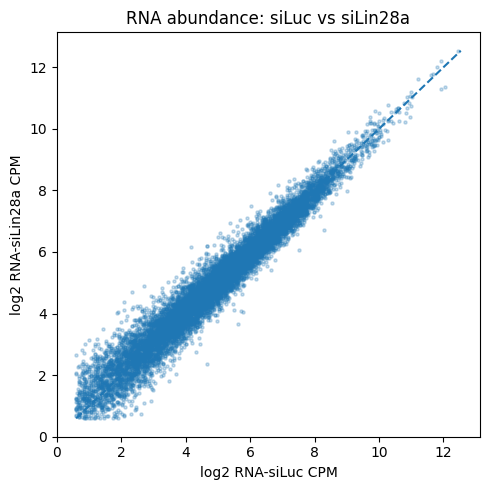

In [53]:
#6-1. RNA-siLuc vs RNA-siLin28a scatter plot (knockdown 후 mRNA 양이 전체적으로 많이 바뀌었는지)
x = np.log2(analysis_pc["RNA-siLuc_CPM"] + 0.5)
y = np.log2(analysis_pc["RNA-siLin28a_CPM"] + 0.5)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=5, alpha=0.25)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("log2 RNA-siLuc CPM")
plt.ylabel("log2 RNA-siLin28a CPM")
plt.title("RNA abundance: siLuc vs siLin28a")
plt.tight_layout()

plt.savefig(PLOT_DIR / "01_RNA_siLuc_vs_siLin28a.png", dpi=200)
plt.show()

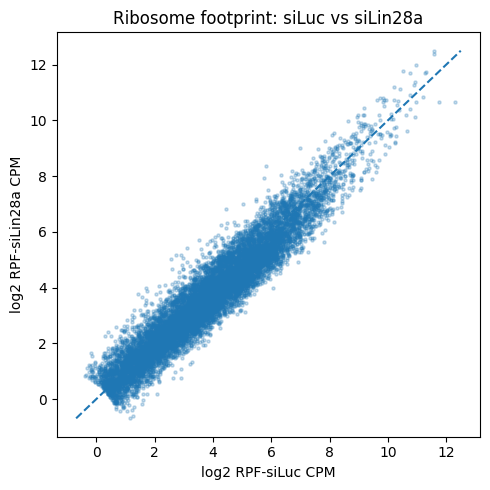

In [54]:
#6-2. RPF-siLuc vs RPF-siLin28a scatter plot
x = np.log2(analysis_pc["RPF-siLuc_CPM"] + 0.5)
y = np.log2(analysis_pc["RPF-siLin28a_CPM"] + 0.5)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=5, alpha=0.25)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("log2 RPF-siLuc CPM")
plt.ylabel("log2 RPF-siLin28a CPM")
plt.title("Ribosome footprint: siLuc vs siLin28a")
plt.tight_layout()

plt.savefig(PLOT_DIR / "02_RPF_siLuc_vs_siLin28a.png", dpi=200)
plt.show()

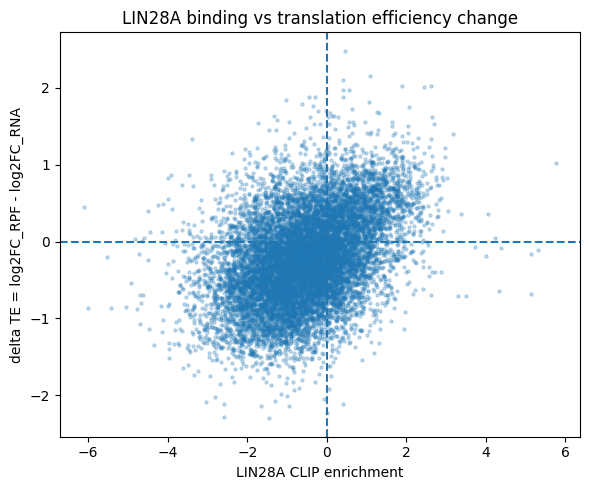

In [55]:
#6-3. CLIP enrichment vs delta_TE scatter plot
x = analysis_pc["CLIP_enrichment"]
y = analysis_pc["delta_TE"]

plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=5, alpha=0.25)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("LIN28A CLIP enrichment")
plt.ylabel("delta TE = log2FC_RPF - log2FC_RNA")
plt.title("LIN28A binding vs translation efficiency change")
plt.tight_layout()

plt.savefig(PLOT_DIR / "03_CLIP_enrichment_vs_delta_TE.png", dpi=200)
plt.show()

In [56]:
#6-4. 상관계수 계산
corr_rows = []

pairs = [
    ("CLIP_enrichment", "log2FC_RNA"),
    ("CLIP_enrichment", "log2FC_RPF"),
    ("CLIP_enrichment", "delta_TE"),
]

for x_col, y_col in pairs:
    temp = analysis_pc[[x_col, y_col]].dropna()
    
    corr_rows.append({
        "x": x_col,
        "y": y_col,
        "pearson": temp[x_col].corr(temp[y_col], method="pearson"),
        "spearman": temp[x_col].corr(temp[y_col], method="spearman"),
        "n_genes": len(temp)
    })

corr_table = pd.DataFrame(corr_rows)

corr_table

,x,y,pearson,spearman,n_genes
0,CLIP_enrichment,log2FC_RNA,-0.224826,-0.251855,11777
1,CLIP_enrichment,log2FC_RPF,0.243613,0.239218,11777
2,CLIP_enrichment,delta_TE,0.412798,0.411846,11777


### Filtering decision

본 분석의 목적은 LIN28A가 mRNA translation, 특히 ER-associated translation에 미치는 영향을 보는 것이다. 따라서 rRNA/tRNA 및 mitochondrial genome-encoded features는 main analysis에서 제외하였다. 그러나 nuclear-encoded mitochondrial proteins는 일반적인 protein-coding mRNA이므로 제거하지 않았다.

논문에서도 mRNA/RefSeq transcript 중심으로 CLIP enrichment와 ribosome density change를 분석했으며, rRNA/tRNA reads는 subsequent analysis에서 제외하였다. 또한 histone mRNA는 poly(A) RNA-seq normalization 문제로 CLIP enrichment가 과대평가될 수 있다고 언급되어 있어, histone 제외 여부를 sensitivity analysis로 확인한다.

In [57]:
# 전체 protein-coding set: chrM 포함
analysis_pc_all = master_annot[
    (master_annot["gene_type"] == "protein_coding") &
    (master_annot["RNA-siLuc_CPM"] >= 1) &
    (master_annot["RNA-siLin28a_CPM"] >= 1) &
    ((master_annot["RPF-siLuc"] + master_annot["RPF-siLin28a"]) >= 20)
].copy()

# chrM 제외
analysis_pc_no_chrM = analysis_pc_all[
    ~analysis_pc_all["Chr"].astype(str).str.contains("chrM", na=False)
].copy()

# histone gene 표시
# mouse GENCODE symbol에서 H1f, H2a/H2b/H3/H4 계열을 넓게 잡음
histone_pattern = r"^(Hist|H1f|H2a|H2b|H3|H4|H2ac|H2bc|H3c|H4c)"

analysis_pc_no_chrM["is_histone"] = analysis_pc_no_chrM["gene_name"].astype(str).str.contains(
    histone_pattern,
    regex=True,
    case=False,
    na=False
)

# chrM + histone 제외
analysis_pc_no_chrM_no_histone = analysis_pc_no_chrM[
    ~analysis_pc_no_chrM["is_histone"]
].copy()

print("protein-coding, chrM 포함:", len(analysis_pc_all))
print("protein-coding, chrM 제외:", len(analysis_pc_no_chrM))
print("protein-coding, chrM + histone 제외:", len(analysis_pc_no_chrM_no_histone))



def make_corr_table(df, label):
    rows = []
    pairs = [
        ("CLIP_enrichment", "log2FC_RNA"),
        ("CLIP_enrichment", "log2FC_RPF"),
        ("CLIP_enrichment", "delta_TE"),
    ]

    for x_col, y_col in pairs:
        temp = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        rows.append({
            "set": label,
            "x": x_col,
            "y": y_col,
            "pearson": temp[x_col].corr(temp[y_col], method="pearson"),
            "spearman": temp[x_col].corr(temp[y_col], method="spearman"),
            "n_genes": len(temp)
        })

    return pd.DataFrame(rows)

corr_compare = pd.concat(
    [
        make_corr_table(analysis_pc_all, "protein_coding_all_chr"),
        make_corr_table(analysis_pc_no_chrM, "protein_coding_no_chrM"),
        make_corr_table(analysis_pc_no_chrM_no_histone, "protein_coding_no_chrM_no_histone"),
    ],
    ignore_index=True
)

corr_compare

protein-coding, chrM 포함: 11788
protein-coding, chrM 제외: 11777
protein-coding, chrM + histone 제외: 11756


/tmp/ipykernel_1189/4017428318.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  analysis_pc_no_chrM["is_histone"] = analysis_pc_no_chrM["gene_name"].astype(str).str.contains(


,set,x,y,pearson,spearman,n_genes
0,protein_coding_all_chr,CLIP_enrichment,log2FC_RNA,-0.223003,-0.250821,11788
1,protein_coding_all_chr,CLIP_enrichment,log2FC_RPF,0.239944,0.237367,11788
2,protein_coding_all_chr,CLIP_enrichment,delta_TE,0.407489,0.409339,11788
3,protein_coding_no_chrM,CLIP_enrichment,log2FC_RNA,-0.224826,-0.251855,11777
4,protein_coding_no_chrM,CLIP_enrichment,log2FC_RPF,0.243613,0.239218,11777
5,protein_coding_no_chrM,CLIP_enrichment,delta_TE,0.412798,0.411846,11777
6,protein_coding_no_chrM_no_histone,CLIP_enrichment,log2FC_RNA,-0.224129,-0.251582,11756
7,protein_coding_no_chrM_no_histone,CLIP_enrichment,log2FC_RPF,0.245648,0.239670,11756
8,protein_coding_no_chrM_no_histone,CLIP_enrichment,delta_TE,0.414407,0.412046,11756


## Step 7. LIN28A binding strength별 binning 분석

이 단계의 목표:
- main analysis set과 sensitivity analysis set을 정한다.
- LIN28A CLIP enrichment 기준으로 gene을 4개 그룹으로 나눈다.
- 각 그룹에서 RNA 변화, RPF 변화, delta_TE 분포를 비교한다.
- 논문 Figure 4E와 비슷하게 strong binder에서 translation derepression이 커지는지 확인한다.

In [58]:
# histone pattern: warning이 나지 않도록 non-capturing group 사용
histone_pattern = r"^(?:Hist|H1f|H2a|H2b|H3|H4|H2ac|H2bc|H3c|H4c)"

# broad main set: protein-coding + no chrM
analysis_main = analysis_pc_no_chrM.copy()

analysis_main["is_histone"] = analysis_main["gene_name"].astype(str).str.contains(
    histone_pattern,
    regex=True,
    case=False,
    na=False
)

# sensitivity set: protein-coding + no chrM + no histone
analysis_no_histone = analysis_main[~analysis_main["is_histone"]].copy()

print("analysis_main:", len(analysis_main))
print("analysis_no_histone:", len(analysis_no_histone))

analysis_main: 11777
analysis_no_histone: 11756


In [59]:
analysis_paperlike = analysis_main[
    (analysis_main["RNA-control"] >= 30) &
    (analysis_main["RPF-siLuc"] >= 80)
].copy()

# 논문 cumulative distribution 분석처럼 histone도 제외한 버전
analysis_paperlike_no_histone = analysis_paperlike[
    ~analysis_paperlike["is_histone"]
].copy()

print("analysis_main:", len(analysis_main))
print("analysis_no_histone:", len(analysis_no_histone))
print("analysis_paperlike:", len(analysis_paperlike))
print("analysis_paperlike_no_histone:", len(analysis_paperlike_no_histone))

analysis_main: 11777
analysis_no_histone: 11756
analysis_paperlike: 8337
analysis_paperlike_no_histone: 8324


In [60]:
def make_corr_table(df, label):
    rows = []
    pairs = [
        ("CLIP_enrichment", "log2FC_RNA"),
        ("CLIP_enrichment", "log2FC_RPF"),
        ("CLIP_enrichment", "delta_TE"),
    ]

    for x_col, y_col in pairs:
        temp = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        rows.append({
            "set": label,
            "x": x_col,
            "y": y_col,
            "pearson": temp[x_col].corr(temp[y_col], method="pearson"),
            "spearman": temp[x_col].corr(temp[y_col], method="spearman"),
            "n_genes": len(temp)
        })

    return pd.DataFrame(rows)

corr_compare2 = pd.concat(
    [
        make_corr_table(analysis_main, "main_no_chrM"),
        make_corr_table(analysis_no_histone, "no_chrM_no_histone"),
        make_corr_table(analysis_paperlike, "paperlike"),
        make_corr_table(analysis_paperlike_no_histone, "paperlike_no_histone"),
    ],
    ignore_index=True
)

corr_compare2

,set,x,y,pearson,spearman,n_genes
0,main_no_chrM,CLIP_enrichment,log2FC_RNA,-0.224826,-0.251855,11777
1,main_no_chrM,CLIP_enrichment,log2FC_RPF,0.243613,0.239218,11777
2,main_no_chrM,CLIP_enrichment,delta_TE,0.412798,0.411846,11777
3,no_chrM_no_histone,CLIP_enrichment,log2FC_RNA,-0.224129,-0.251582,11756
4,no_chrM_no_histone,CLIP_enrichment,log2FC_RPF,0.245648,0.239670,11756
5,no_chrM_no_histone,CLIP_enrichment,delta_TE,0.414407,0.412046,11756
6,paperlike,CLIP_enrichment,log2FC_RNA,-0.278241,-0.299825,8337
7,paperlike,CLIP_enrichment,log2FC_RPF,0.289639,0.271440,8337
8,paperlike,CLIP_enrichment,delta_TE,0.491551,0.474956,8337
9,paperlike_no_histone,CLIP_enrichment,log2FC_RNA,-0.277971,-0.299540,8324


In [62]:
#10
df = analysis_paperlike_no_histone.copy()

# CLIP_enrichment가 낮은 gene부터 높은 gene까지 rank percent 계산
df["clip_rank_pct"] = df["CLIP_enrichment"].rank(pct=True, method="first")

# rank 기준으로 네 그룹 만들기
df["LIN28A_binding_group"] = pd.cut(
    df["clip_rank_pct"],
    bins=[0, 0.50, 0.80, 0.95, 1.00],
    labels=["bottom 50%", "20-50%", "5-20%", "top 5%"],
    include_lowest=True
)

# 보기 좋은 순서 지정
group_order = ["bottom 50%", "20-50%", "5-20%", "top 5%"]

df["LIN28A_binding_group"] = pd.Categorical(
    df["LIN28A_binding_group"],
    categories=group_order,
    ordered=True
)

df["LIN28A_binding_group"].value_counts().sort_index()

LIN28A_binding_group
bottom 50%    4162
20-50%        2497
5-20%         1248
top 5%         417
Name: count, dtype: int64

In [63]:
bin_summary = df.groupby("LIN28A_binding_group").agg(
    n_genes=("Geneid", "count"),
    median_CLIP_enrichment=("CLIP_enrichment", "median"),
    median_log2FC_RNA=("log2FC_RNA", "median"),
    median_log2FC_RPF=("log2FC_RPF", "median"),
    median_delta_TE=("delta_TE", "median"),
    mean_delta_TE=("delta_TE", "mean")
).reset_index()

bin_summary

,LIN28A_binding_group,n_genes,median_CLIP_enrichment,median_log2FC_RNA,median_log2FC_RPF,median_delta_TE,mean_delta_TE
0,bottom 50%,4162,-1.320401,0.096675,-0.389554,-0.507763,-0.490337
1,20-50%,2497,-0.115253,-0.073339,-0.307776,-0.213811,-0.208178
2,5-20%,1248,0.801868,-0.084848,0.053997,0.160249,0.106418
3,top 5%,417,1.786981,-0.116291,0.426235,0.503970,0.444906


<Figure size 600x400 with 0 Axes>

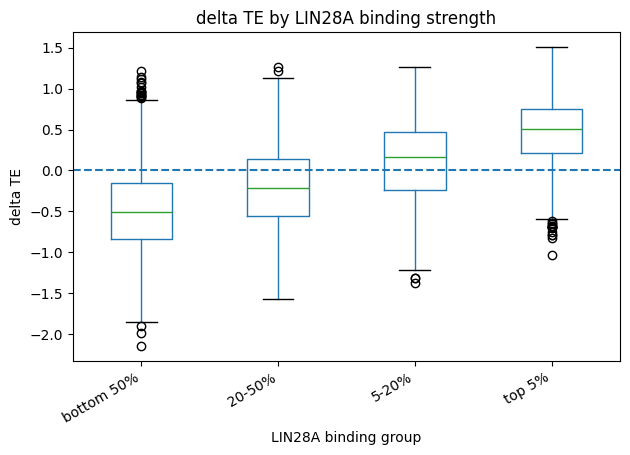

In [64]:
PLOT_DIR = DATA_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

plt.figure(figsize=(6, 4))

df.boxplot(
    column="delta_TE",
    by="LIN28A_binding_group",
    grid=False
)

plt.axhline(0, linestyle="--")
plt.xlabel("LIN28A binding group")
plt.ylabel("delta TE")
plt.title("delta TE by LIN28A binding strength")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(PLOT_DIR / "04_delta_TE_by_LIN28A_binding_group_boxplot.png", dpi=200)
plt.show()

<Figure size 600x400 with 0 Axes>

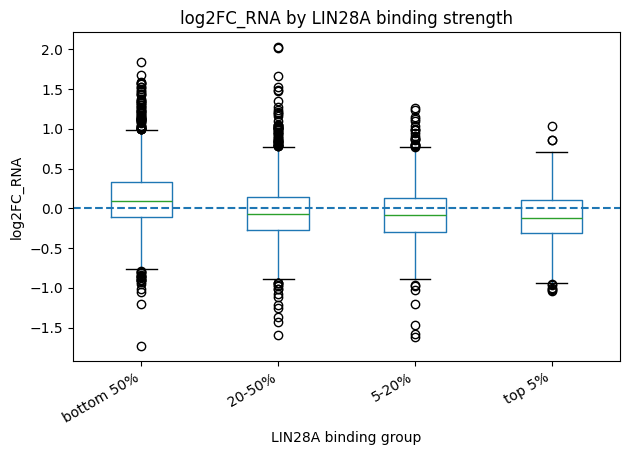

<Figure size 600x400 with 0 Axes>

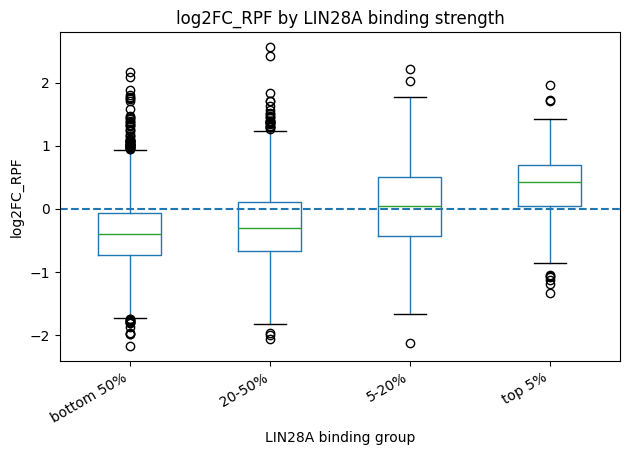

<Figure size 600x400 with 0 Axes>

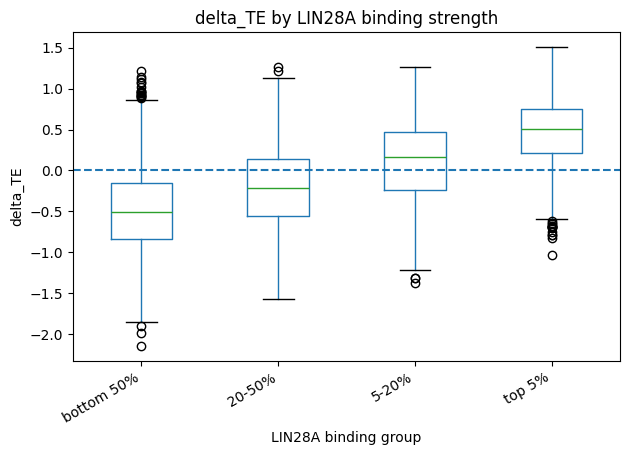

In [65]:
for y_col in ["log2FC_RNA", "log2FC_RPF", "delta_TE"]:
    plt.figure(figsize=(6, 4))

    df.boxplot(
        column=y_col,
        by="LIN28A_binding_group",
        grid=False
    )

    plt.axhline(0, linestyle="--")
    plt.xlabel("LIN28A binding group")
    plt.ylabel(y_col)
    plt.title(f"{y_col} by LIN28A binding strength")
    plt.suptitle("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(PLOT_DIR / f"05_{y_col}_by_LIN28A_binding_group_boxplot.png", dpi=200)
    plt.show()

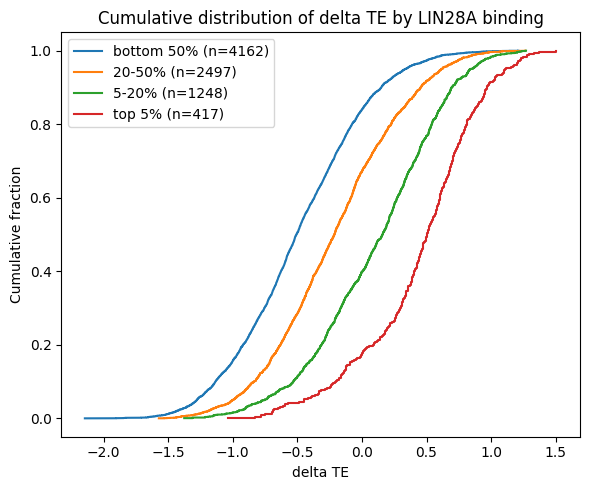

In [66]:
plt.figure(figsize=(6, 5))

for group in group_order:
    values = df.loc[df["LIN28A_binding_group"] == group, "delta_TE"].dropna().sort_values()
    y = np.arange(1, len(values) + 1) / len(values)
    plt.step(values, y, where="post", label=f"{group} (n={len(values)})")

plt.xlabel("delta TE")
plt.ylabel("Cumulative fraction")
plt.title("Cumulative distribution of delta TE by LIN28A binding")
plt.legend()
plt.tight_layout()

plt.savefig(PLOT_DIR / "06_delta_TE_CDF_by_LIN28A_binding_group.png", dpi=200)
plt.show()

In [ ]:
from scipy.stats import ks_2samp, mannwhitneyu

baseline_group = "bottom 50%"
baseline_values = df.loc[
    df["LIN28A_binding_group"] == baseline_group,
    "delta_TE"
].dropna()

test_rows = []

for group in ["20-50%", "5-20%", "top 5%"]:
    group_values = df.loc[
        df["LIN28A_binding_group"] == group,
        "delta_TE"
    ].dropna()

    ks_result = ks_2samp(group_values, baseline_values)
    mw_result = mannwhitneyu(group_values, baseline_values, alternative="two-sided")

    test_rows.append({
        "comparison": f"{group} vs {baseline_group}",
        "n_group": len(group_values),
        "n_baseline": len(baseline_values),
        "median_group": group_values.median(),
        "median_baseline": baseline_values.median(),
        "median_difference": group_values.median() - baseline_values.median(),
        "KS_pvalue": ks_result.pvalue,
        "MWU_pvalue": mw_result.pvalue
    })

test_table = pd.DataFrame(test_rows)
test_table



,comparison,n_group,n_baseline,median_group,median_baseline,median_difference,KS_pvalue,MWU_pvalue
0,20-50% vs bottom 50%,2497,4162,-0.213811,-0.507763,0.293952,1.823528e-70,1.159463e-101
1,5-20% vs bottom 50%,1248,4162,0.160249,-0.507763,0.668012,1.034551e-176,2.298142e-233
2,top 5% vs bottom 50%,417,4162,0.503970,-0.507763,1.011734,3.904422e-174,1.975501e-168


In [69]:
#15. strong binder 후보 gene 보기
top5 = df[df["LIN28A_binding_group"] == "top 5%"].copy()

top5_sorted = top5.sort_values("delta_TE", ascending=False)

top5_sorted[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control_CPM",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].head(30)

,Geneid,gene_name,gene_type,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control_CPM,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
10388,ENSMUSG00000055373.9,Fut9,protein_coding,1.630399,-0.863254,0.641950,1.505204,42.228015,53.915794,29.412981,8.133286,12.971701
52400,ENSMUSG00000025666.17,Tmem47,protein_coding,1.710215,-0.739679,0.671667,1.411346,15.877734,22.284581,13.145060,13.419922,21.673215
9368,ENSMUSG00000027966.21,Col11a1,protein_coding,1.878956,0.593107,1.961816,1.368710,5.996378,10.866035,16.645568,32.058702,126.333090
36152,ENSMUSG00000021072.13,Tmx1,protein_coding,2.623370,-0.349864,0.983524,1.333388,28.039402,45.582098,35.658700,25.179297,50.275413
10135,ENSMUSG00000028232.14,Tmem68,protein_coding,1.922319,-0.515485,0.776196,1.291681,8.332995,12.983991,8.932831,5.625523,9.990627
8364,ENSMUSG00000027995.11,Tlr2,protein_coding,1.592452,0.445570,1.726844,1.281274,5.489642,11.759260,16.195296,6.709961,23.365176
51717,ENSMUSG00000016534.16,Lamp2,protein_coding,2.138708,-0.132887,1.143719,1.276606,49.997970,66.301988,60.423703,96.650546,214.153924
41149,ENSMUSG00000036242.16,Armh4,protein_coding,1.464428,-0.497653,0.751966,1.249619,14.306852,25.461515,17.887450,64.844880,109.546420
14860,ENSMUSG00000046079.17,Lrrc8d,protein_coding,1.425459,-0.650265,0.583125,1.233390,35.031155,54.007880,34.230415,23.676899,35.719177
5865,ENSMUSG00000033808.17,Tmem87a,protein_coding,2.256424,-0.374659,0.857513,1.232172,30.868679,48.782053,37.510628,61.248806,111.383406


In [70]:
top5_low_TE = top5.sort_values("delta_TE", ascending=True)

top5_low_TE[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].head(30)

,Geneid,gene_name,gene_type,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
52390,ENSMUSG00000046942.18,Mageb16,protein_coding,1.602718,-0.029121,-1.066665,-1.037544,10.810372,10.166607,4.592466
32392,ENSMUSG00000042302.15,Ehbp1,protein_coding,1.464933,0.431574,-0.393526,-0.825100,35.133709,17.249344,13.011986
27752,ENSMUSG00000032050.19,Rdx,protein_coding,1.482551,-0.291897,-1.075793,-0.783895,166.130642,69.675148,32.791816
52766,ENSMUSG00000056537.12,Rlim,protein_coding,1.511228,-0.552140,-1.335217,-0.783078,174.232790,74.351788,29.166185
31024,ENSMUSG00000073427.5,Gm4924,protein_coding,1.725563,-0.069583,-0.819868,-0.750285,17.391312,6.424812,3.422864
14911,ENSMUSG00000033773.15,Rpap2,protein_coding,1.459323,-0.482791,-1.179981,-0.697191,23.352092,13.137516,5.519016
4045,ENSMUSG00000014873.16,Surf2,protein_coding,1.523939,0.096451,-0.600299,-0.696750,35.442242,16.808791,10.917177
30014,ENSMUSG00000069662.6,Marcks,protein_coding,2.619998,-0.151229,-0.842922,-0.691692,34.964796,33.346472,18.369863
10926,ENSMUSG00000038729.25,Pakap,protein_coding,1.531081,0.116947,-0.573998,-0.690945,51.808144,32.228145,21.485219
10925,ENSMUSG00000089945.14,Pakap,protein_coding,1.635869,0.113726,-0.570934,-0.684660,48.373599,28.568166,19.068132


### Interpretation

Filtering sensitivity analysis showed that the positive association between LIN28A CLIP enrichment and delta_TE was robust to removal of chrM genes and histone genes. Therefore, the observed relationship is unlikely to be driven solely by mitochondrial genome-encoded features or histone-related normalization artifacts.

Next, genes were divided into four groups according to LIN28A CLIP enrichment: bottom 50%, 20–50%, 5–20%, and top 5%. This follows the strategy used in the original paper. If the top 5% LIN28A binders show higher delta_TE than weak binders, it supports the idea that LIN28A-bound mRNAs are translationally derepressed after Lin28a knockdown.

### Result 1. LIN28A binding strength predicts translational derepression

Genes were divided into four groups based on LIN28A CLIP enrichment. The cumulative distribution of delta_TE shifted progressively to the right as LIN28A binding strength increased. The top 5% LIN28A-bound genes showed the highest median delta_TE, whereas weak binders showed the lowest median delta_TE.

This reproduces the central pattern of the original study: LIN28A-bound mRNAs tend to show increased ribosome occupancy / translation efficiency after Lin28a knockdown. Therefore, LIN28A appears to act mainly as a translational repressor for its bound mRNAs rather than as a simple stabilizer of mRNA abundance.

In [71]:
binned_out = DATA_DIR / "02_paperlike_no_histone_binned.tsv"
df.to_csv(binned_out, sep="\t", index=False)

print("저장 완료:")
print(binned_out)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/02_paperlike_no_histone_binned.tsv


In [73]:
validation_genes = ["Lamp1", "Epcam", "Cdh1", "Eif4g1", "Mcm7", "Tuba1a", "Tubb5"]

validation_table = analysis_main[
    analysis_main["gene_name"].isin(validation_genes)
][
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control",
        "RPF-siLuc",
        "RPF-siLin28a",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].sort_values("CLIP_enrichment", ascending=False)

validation_table

,Geneid,gene_name,gene_type,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control,RPF-siLuc,RPF-siLin28a,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
26126,ENSMUSG00000000303.13,Cdh1,protein_coding,1.683207,0.082313,0.759689,0.677375,2130.750000,7620.000000,10857.500000,330.838549,350.292864,516.463648,874.784136
24319,ENSMUSG00000031447.8,Lamp1,protein_coding,0.911554,0.040361,0.822447,0.782086,1363.633333,7897.950000,11754.000000,238.491061,245.271578,535.302371,947.014758
44163,ENSMUSG00000072235.7,Tuba1a,protein_coding,0.721662,0.127827,-0.686289,-0.814116,802.452778,550.611111,285.500000,85.207828,93.148368,37.318979,23.002613
48251,ENSMUSG00000045394.10,Epcam,protein_coding,0.660148,0.091647,0.731339,0.639693,2032.000000,4514.500000,6309.000000,296.237593,315.699326,305.980989,508.313434
44850,ENSMUSG00000045983.17,Eif4g1,protein_coding,0.007724,0.022876,-0.635850,-0.658726,4700.010714,4243.700000,2295.250000,851.648549,865.268160,287.626874,184.927312
15843,ENSMUSG00000029730.17,Mcm7,protein_coding,-1.903844,-0.103099,-1.319987,-1.216888,2385.982241,1829.590909,612.750000,426.494449,397.044979,124.004881,49.369006
47202,ENSMUSG00000001525.11,Tubb5,protein_coding,-2.886924,0.081717,-1.034260,-1.115977,11831.996970,17872.500000,7337.833333,1748.004388,1849.902185,1211.351253,591.206096


In [74]:
lin28_table = master_annot[
    master_annot["gene_name"].astype(str).str.lower().str.contains("lin28", na=False)
][
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "CLIP_enrichment"
    ]
].sort_values("gene_name")

lin28_table

,Geneid,gene_name,gene_type,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM,log2FC_RNA,log2FC_RPF,delta_TE,CLIP_enrichment
12293,ENSMUSG00000050966.10,Lin28a,protein_coding,314.884815,104.013706,65.777949,15.509643,-1.593421,-2.049588,-0.456167,-0.328651
30191,ENSMUSG00000063804.9,Lin28b,protein_coding,41.714526,26.435370,4.947749,3.800198,-0.648238,-0.341257,0.306981,1.512149


In [75]:
#12
top5 = df[df["LIN28A_binding_group"] == "top 5%"].copy()

top5_high_TE = top5.sort_values("delta_TE", ascending=False)[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control_CPM",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].head(50)

top5_high_TE

,Geneid,gene_name,gene_type,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control_CPM,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
10388,ENSMUSG00000055373.9,Fut9,protein_coding,1.630399,-0.863254,0.641950,1.505204,42.228015,53.915794,29.412981,8.133286,12.971701
52400,ENSMUSG00000025666.17,Tmem47,protein_coding,1.710215,-0.739679,0.671667,1.411346,15.877734,22.284581,13.145060,13.419922,21.673215
9368,ENSMUSG00000027966.21,Col11a1,protein_coding,1.878956,0.593107,1.961816,1.368710,5.996378,10.866035,16.645568,32.058702,126.333090
36152,ENSMUSG00000021072.13,Tmx1,protein_coding,2.623370,-0.349864,0.983524,1.333388,28.039402,45.582098,35.658700,25.179297,50.275413
10135,ENSMUSG00000028232.14,Tmem68,protein_coding,1.922319,-0.515485,0.776196,1.291681,8.332995,12.983991,8.932831,5.625523,9.990627
8364,ENSMUSG00000027995.11,Tlr2,protein_coding,1.592452,0.445570,1.726844,1.281274,5.489642,11.759260,16.195296,6.709961,23.365176
51717,ENSMUSG00000016534.16,Lamp2,protein_coding,2.138708,-0.132887,1.143719,1.276606,49.997970,66.301988,60.423703,96.650546,214.153924
41149,ENSMUSG00000036242.16,Armh4,protein_coding,1.464428,-0.497653,0.751966,1.249619,14.306852,25.461515,17.887450,64.844880,109.546420
14860,ENSMUSG00000046079.17,Lrrc8d,protein_coding,1.425459,-0.650265,0.583125,1.233390,35.031155,54.007880,34.230415,23.676899,35.719177
5865,ENSMUSG00000033808.17,Tmem87a,protein_coding,2.256424,-0.374659,0.857513,1.232172,30.868679,48.782053,37.510628,61.248806,111.383406


In [76]:
top5_low_TE = top5.sort_values("delta_TE", ascending=True)[
    [
        "Geneid",
        "gene_name",
        "gene_type",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control_CPM",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].head(50)

top5_low_TE

,Geneid,gene_name,gene_type,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control_CPM,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
52390,ENSMUSG00000046942.18,Mageb16,protein_coding,1.602718,-0.029121,-1.066665,-1.037544,10.810372,7.643059,7.480338,10.166607,4.592466
32392,ENSMUSG00000042302.15,Ehbp1,protein_coding,1.464933,0.431574,-0.393526,-0.825100,35.133709,38.371839,51.926620,17.249344,13.011986
27752,ENSMUSG00000032050.19,Rdx,protein_coding,1.482551,-0.291897,-1.075793,-0.783895,166.130642,201.850421,164.785316,69.675148,32.791816
52766,ENSMUSG00000056537.12,Rlim,protein_coding,1.511228,-0.552140,-1.335217,-0.783078,174.232790,228.309524,155.549883,74.351788,29.166185
31024,ENSMUSG00000073427.5,Gm4924,protein_coding,1.725563,-0.069583,-0.819868,-0.750285,17.391312,12.391578,11.784559,6.424812,3.422864
14911,ENSMUSG00000033773.15,Rpap2,protein_coding,1.459323,-0.482791,-1.179981,-0.697191,23.352092,32.506021,23.118845,13.137516,5.519016
4045,ENSMUSG00000014873.16,Surf2,protein_coding,1.523939,0.096451,-0.600299,-0.696750,35.442242,28.311036,30.303036,16.808791,10.917177
30014,ENSMUSG00000069662.6,Marcks,protein_coding,2.619998,-0.151229,-0.842922,-0.691692,34.964796,51.107201,45.971399,33.346472,18.369863
10926,ENSMUSG00000038729.25,Pakap,protein_coding,1.531081,0.116947,-0.573998,-0.690945,51.808144,61.657077,66.905453,32.228145,21.485219
10925,ENSMUSG00000089945.14,Pakap,protein_coding,1.635869,0.113726,-0.570934,-0.684660,48.373599,60.730088,65.752104,28.568166,19.068132


In [77]:
top5_low_TE_out = DATA_DIR / "03_top5_LIN28A_binders_low_deltaTE.tsv"
top5_low_TE.to_csv(top5_low_TE_out, sep="\t", index=False)

print("저장 완료:")
print(top5_low_TE_out)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/03_top5_LIN28A_binders_low_deltaTE.tsv


In [78]:
gene_list_dir = DATA_DIR / "gene_lists"
gene_list_dir.mkdir(exist_ok=True)

# 1. LIN28A top 5% binder 전체
top5_genes = top5["gene_name"].dropna().astype(str).drop_duplicates()

# 2. top 5% binder 중 delta_TE도 높은 gene
# 기준은 일단 delta_TE 상위 25%로 잡자
delta_cut = top5["delta_TE"].quantile(0.75)

top5_high_delta_genes = top5[
    top5["delta_TE"] >= delta_cut
]["gene_name"].dropna().astype(str).drop_duplicates()

# 3. background gene list
background_genes = df["gene_name"].dropna().astype(str).drop_duplicates()

(top5_genes.to_csv(gene_list_dir / "LIN28A_top5_binders_gene_symbols.txt", index=False, header=False))
(top5_high_delta_genes.to_csv(gene_list_dir / "LIN28A_top5_binders_high_deltaTE_gene_symbols.txt", index=False, header=False))
(background_genes.to_csv(gene_list_dir / "background_paperlike_no_histone_gene_symbols.txt", index=False, header=False))

print("top5 genes:", len(top5_genes))
print("top5 high delta_TE genes:", len(top5_high_delta_genes))
print("background genes:", len(background_genes))
print("저장 위치:", gene_list_dir)

top5 genes: 416
top5 high delta_TE genes: 105
background genes: 8317
저장 위치: /home/ssy010622/bioinfo1_project/binfo1-work/gene_lists


## Step 16. Strong LIN28A binders 내부 비교

이 단계의 목표:
- LIN28A top 5% binder 안에서 delta_TE가 높은 gene과 낮은 gene을 나눈다.
- high delta_TE group이 단순히 low-count artifact인지 확인한다.
- CLIP strength, baseline RNA/RPF abundance, gene length 등을 비교한다.

LIN28A가 강하게 붙은 gene들 중에서도
delta_TE가 높은 gene과 낮은 gene은 무엇이 다른가?

In [81]:
top5 = df[df["LIN28A_binding_group"] == "top 5%"].copy()

q25 = top5["delta_TE"].quantile(0.25)
q75 = top5["delta_TE"].quantile(0.75)

print("top5 delta_TE 25% quantile:", q25)
print("top5 delta_TE 75% quantile:", q75)

top5["effect_group"] = "middle"
top5.loc[top5["delta_TE"] <= q25, "effect_group"] = "low_delta_TE"
top5.loc[top5["delta_TE"] >= q75, "effect_group"] = "high_delta_TE"

top5["effect_group"].value_counts()

top5 delta_TE 25% quantile: 0.2116663365764315
top5 delta_TE 75% quantile: 0.7555375456701834


effect_group
middle           207
low_delta_TE     105
high_delta_TE    105
Name: count, dtype: int64

In [82]:
top5_extreme = top5[
    top5["effect_group"].isin(["high_delta_TE", "low_delta_TE"])
].copy()

top5_extreme["effect_group"] = pd.Categorical(
    top5_extreme["effect_group"],
    categories=["low_delta_TE", "high_delta_TE"],
    ordered=True
)

print(top5_extreme["effect_group"].value_counts().sort_index())

effect_group
low_delta_TE     105
high_delta_TE    105
Name: count, dtype: int64


In [83]:
top5_extreme["log2_RNA_control_CPM"] = np.log2(top5_extreme["RNA-control_CPM"] + 0.5)
top5_extreme["log2_RNA_siLuc_CPM"] = np.log2(top5_extreme["RNA-siLuc_CPM"] + 0.5)
top5_extreme["log2_RPF_siLuc_CPM"] = np.log2(top5_extreme["RPF-siLuc_CPM"] + 0.5)
top5_extreme["log2_length"] = np.log2(top5_extreme["Length"] + 1)

top5["log2_RNA_control_CPM"] = np.log2(top5["RNA-control_CPM"] + 0.5)
top5["log2_RNA_siLuc_CPM"] = np.log2(top5["RNA-siLuc_CPM"] + 0.5)
top5["log2_RPF_siLuc_CPM"] = np.log2(top5["RPF-siLuc_CPM"] + 0.5)
top5["log2_length"] = np.log2(top5["Length"] + 1)


In [84]:
compare_features = [
    "CLIP_enrichment",
    "log2FC_RNA",
    "log2FC_RPF",
    "delta_TE",
    "log2_RNA_control_CPM",
    "log2_RNA_siLuc_CPM",
    "log2_RPF_siLuc_CPM",
    "log2_length"
]

feature_summary = top5_extreme.groupby("effect_group")[compare_features].agg(
    ["count", "median", "mean"]
)

feature_summary

CLIP_enrichment                     log2FC_RNA            \
                        count    median      mean      count    median   
effect_group                                                             
low_delta_TE              105  1.725563  1.832953        105 -0.101990   
high_delta_TE             105  1.804809  1.897538        105 -0.218788   

                        log2FC_RPF                     delta_TE  ...  \
                   mean      count    median      mean    count  ...   
effect_group                                                     ...   
low_delta_TE  -0.074553        105 -0.273906 -0.265098      105  ...   
high_delta_TE -0.206277        105  0.730274  0.762019      105  ...   

              log2_RNA_control_CPM log2_RNA_siLuc_CPM                      \
                              mean              count    median      mean   
effect_group                                                                
low_delta_TE              5.901282                105  6.129782  6.243806   
high_delta_TE             5.090936                105  5.575723  5.516115   

              log2_RPF_siLuc_CPM                    log2_length             \
                           count   median      mean       count     median   
effect_group                                                                 
low_delta_TE                 105  4.89133  4.890128         105  12.621823   
high_delta_TE                105  4.87809  5.055112         105  12.816184   

                          
                    mean  
effect_group              
low_delta_TE   12.541068  
high_delta_TE  12.724242  

[2 rows x 24 columns]

In [85]:
from scipy.stats import mannwhitneyu

test_rows = []

for col in compare_features:
    low_values = top5_extreme.loc[
        top5_extreme["effect_group"] == "low_delta_TE", col
    ].dropna()
    
    high_values = top5_extreme.loc[
        top5_extreme["effect_group"] == "high_delta_TE", col
    ].dropna()
    
    result = mannwhitneyu(high_values, low_values, alternative="two-sided")
    
    test_rows.append({
        "feature": col,
        "median_low_delta_TE": low_values.median(),
        "median_high_delta_TE": high_values.median(),
        "median_difference_high_minus_low": high_values.median() - low_values.median(),
        "MWU_pvalue": result.pvalue,
        "n_low": len(low_values),
        "n_high": len(high_values)
    })

top5_high_low_test = pd.DataFrame(test_rows)
top5_high_low_test

,feature,median_low_delta_TE,median_high_delta_TE,median_difference_high_minus_low,MWU_pvalue,n_low,n_high
0,CLIP_enrichment,1.725563,1.804809,0.079246,4.638598e-02,105,105
1,log2FC_RNA,-0.101990,-0.218788,-0.116798,3.105126e-03,105,105
2,log2FC_RPF,-0.273906,0.730274,1.004180,4.609214e-33,105,105
3,delta_TE,-0.139581,0.942014,1.081595,5.877806e-36,105,105
4,log2_RNA_control_CPM,5.869154,4.987347,-0.881806,4.876178e-04,105,105
5,log2_RNA_siLuc_CPM,6.129782,5.575723,-0.554059,6.599325e-04,105,105
6,log2_RPF_siLuc_CPM,4.891330,4.878090,-0.013240,4.977960e-01,105,105
7,log2_length,12.621823,12.816184,0.194361,4.440318e-01,105,105


<Figure size 500x400 with 0 Axes>

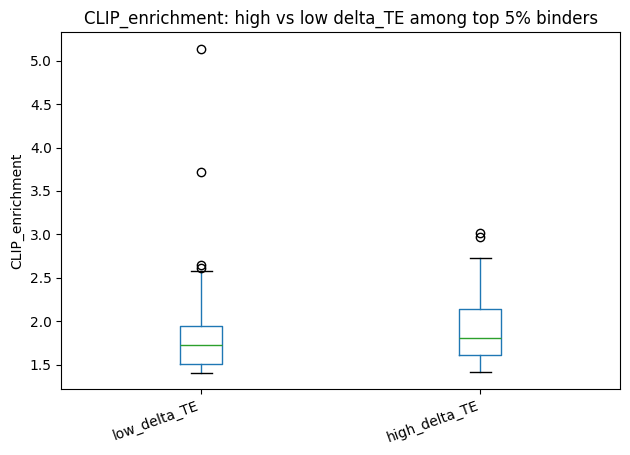

<Figure size 500x400 with 0 Axes>

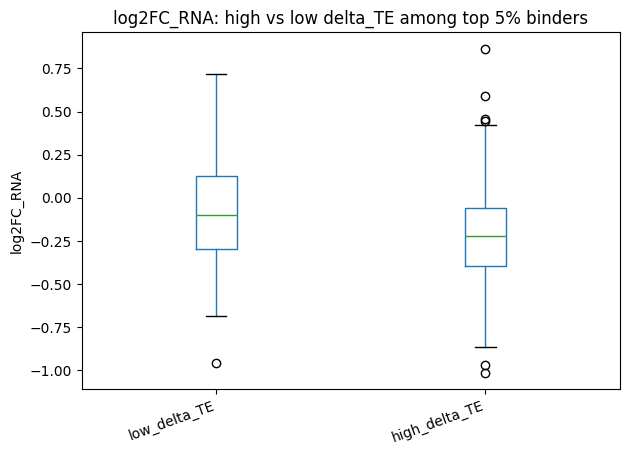

<Figure size 500x400 with 0 Axes>

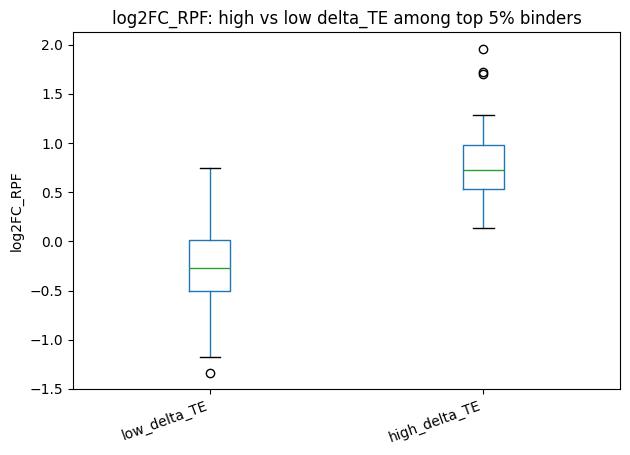

<Figure size 500x400 with 0 Axes>

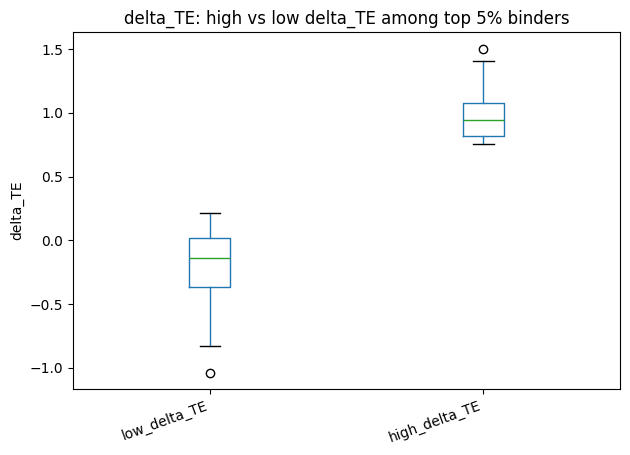

<Figure size 500x400 with 0 Axes>

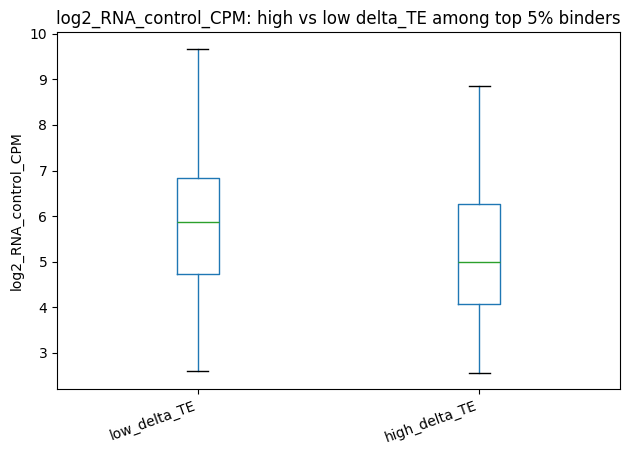

<Figure size 500x400 with 0 Axes>

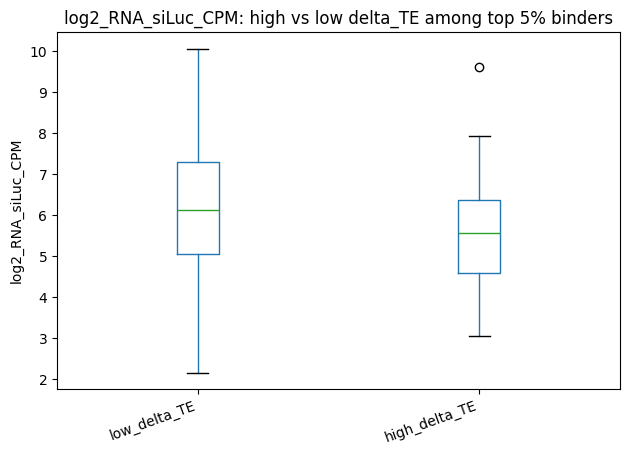

<Figure size 500x400 with 0 Axes>

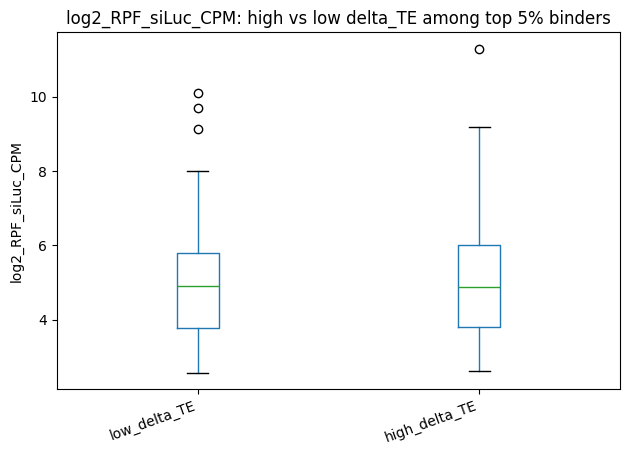

<Figure size 500x400 with 0 Axes>

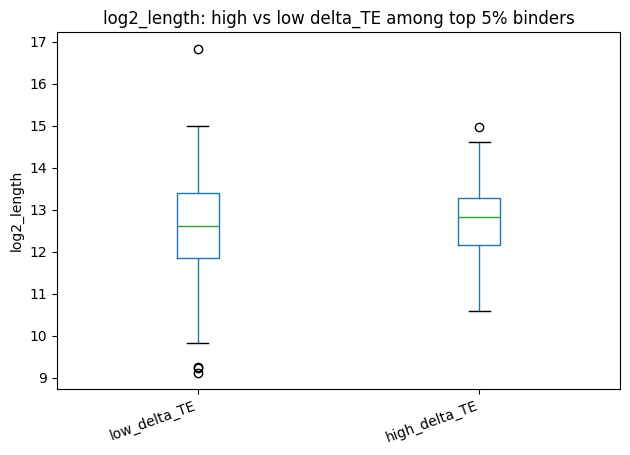

In [86]:
PLOT_DIR = DATA_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

for col in compare_features:
    plt.figure(figsize=(5, 4))
    
    top5_extreme.boxplot(
        column=col,
        by="effect_group",
        grid=False
    )
    
    plt.xlabel("")
    plt.ylabel(col)
    plt.title(f"{col}: high vs low delta_TE among top 5% binders")
    plt.suptitle("")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    
    plt.savefig(PLOT_DIR / f"07_top5_high_vs_low_{col}.png", dpi=200)
    plt.show()

In [90]:
within_top5_corr_rows = []

x_cols = [
    "CLIP_enrichment",
    "log2_RNA_control_CPM",
    "log2_RNA_siLuc_CPM",
    "log2_RPF_siLuc_CPM",
    "log2_length"
]

for x_col in x_cols:
    temp = top5[[x_col, "delta_TE"]].replace([np.inf, -np.inf], np.nan).dropna()
    
    within_top5_corr_rows.append({
        "x": x_col,
        "y": "delta_TE",
        "pearson": temp[x_col].corr(temp["delta_TE"], method="pearson"),
        "spearman": temp[x_col].corr(temp["delta_TE"], method="spearman"),
        "n_genes": len(temp)
    })

within_top5_corr = pd.DataFrame(within_top5_corr_rows)
within_top5_corr

,x,y,pearson,spearman,n_genes
0,CLIP_enrichment,delta_TE,0.051927,0.109524,417
1,log2_RNA_control_CPM,delta_TE,-0.203095,-0.218513,417
2,log2_RNA_siLuc_CPM,delta_TE,-0.178691,-0.208305,417
3,log2_RPF_siLuc_CPM,delta_TE,0.031652,-0.001867,417
4,log2_length,delta_TE,0.068188,0.059967,417


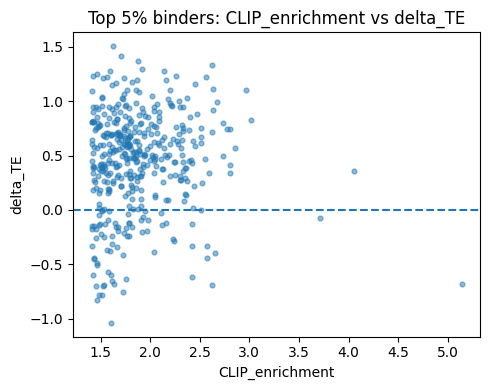

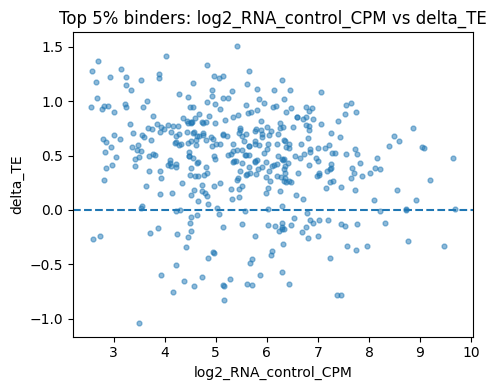

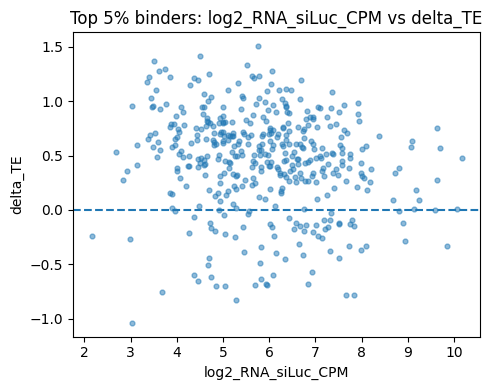

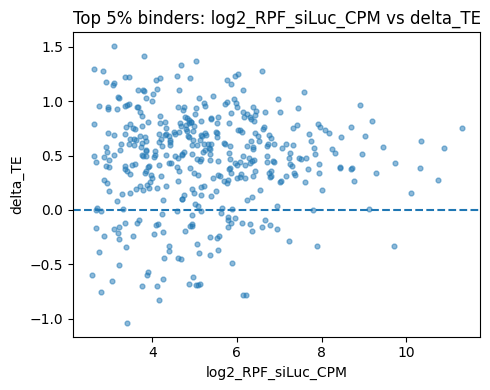

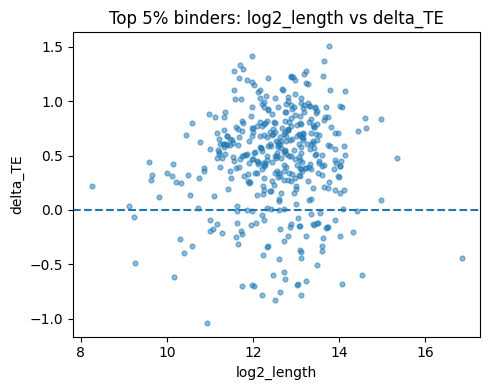

In [91]:
for x_col in x_cols:
    plt.figure(figsize=(5, 4))
    
    plt.scatter(
        top5[x_col],
        top5["delta_TE"],
        s=12,
        alpha=0.5
    )
    
    plt.axhline(0, linestyle="--")
    plt.xlabel(x_col)
    plt.ylabel("delta_TE")
    plt.title(f"Top 5% binders: {x_col} vs delta_TE")
    plt.tight_layout()
    
    plt.savefig(PLOT_DIR / f"08_top5_{x_col}_vs_deltaTE.png", dpi=200)
    plt.show()

In [93]:
functional_targets = top5[
    (top5["delta_TE"] >= 0.5) &
    (top5["log2FC_RPF"] >= 0.3) &
    (top5["log2FC_RNA"] <= 0.3)
].copy()

functional_targets = functional_targets.sort_values(
    ["delta_TE", "CLIP_enrichment"],
    ascending=False
)

print("functional target 후보 수:", len(functional_targets))

functional_targets[
    [
        "Geneid",
        "gene_name",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE",
        "RNA-control_CPM",
        "RNA-siLuc_CPM",
        "RNA-siLin28a_CPM",
        "RPF-siLuc_CPM",
        "RPF-siLin28a_CPM"
    ]
].head(50)

functional target 후보 수: 171


,Geneid,gene_name,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE,RNA-control_CPM,RNA-siLuc_CPM,RNA-siLin28a_CPM,RPF-siLuc_CPM,RPF-siLin28a_CPM
10388,ENSMUSG00000055373.9,Fut9,1.630399,-0.863254,0.641950,1.505204,42.228015,53.915794,29.412981,8.133286,12.971701
52400,ENSMUSG00000025666.17,Tmem47,1.710215,-0.739679,0.671667,1.411346,15.877734,22.284581,13.145060,13.419922,21.673215
36152,ENSMUSG00000021072.13,Tmx1,2.623370,-0.349864,0.983524,1.333388,28.039402,45.582098,35.658700,25.179297,50.275413
10135,ENSMUSG00000028232.14,Tmem68,1.922319,-0.515485,0.776196,1.291681,8.332995,12.983991,8.932831,5.625523,9.990627
51717,ENSMUSG00000016534.16,Lamp2,2.138708,-0.132887,1.143719,1.276606,49.997970,66.301988,60.423703,96.650546,214.153924
41149,ENSMUSG00000036242.16,Armh4,1.464428,-0.497653,0.751966,1.249619,14.306852,25.461515,17.887450,64.844880,109.546420
14860,ENSMUSG00000046079.17,Lrrc8d,1.425459,-0.650265,0.583125,1.233390,35.031155,54.007880,34.230415,23.676899,35.719177
5865,ENSMUSG00000033808.17,Tmem87a,2.256424,-0.374659,0.857513,1.232172,30.868679,48.782053,37.510628,61.248806,111.383406
10244,ENSMUSG00000049488.15,Tmem67,1.565521,-0.217952,1.002132,1.220084,7.080231,10.006575,8.533396,9.675221,19.880542
32525,ENSMUSG00000020311.18,Erlec1,1.740530,-0.590062,0.620316,1.210378,14.413829,20.258710,13.290310,17.802859,27.635363


In [94]:
check_genes = ["Cdh1", "Lamp1", "Lamp2", "Epcam", "Hsp90b1", "P4hb", "Canx"]

functional_targets[
    functional_targets["gene_name"].isin(check_genes)
][
    [
        "gene_name",
        "CLIP_enrichment",
        "log2FC_RNA",
        "log2FC_RPF",
        "delta_TE"
    ]
]

,gene_name,CLIP_enrichment,log2FC_RNA,log2FC_RPF,delta_TE
51717,Lamp2,2.138708,-0.132887,1.143719,1.276606
31139,Hsp90b1,2.330161,-0.309452,0.446086,0.755538
26126,Cdh1,1.683207,0.082313,0.759689,0.677375
32795,Canx,2.860110,-0.196909,0.373825,0.570734


In [95]:
functional_out = DATA_DIR / "04_functional_LIN28A_targets.tsv"
functional_targets.to_csv(functional_out, sep="\t", index=False)

gene_list_dir = DATA_DIR / "gene_lists"
gene_list_dir.mkdir(exist_ok=True)

functional_targets["gene_name"].dropna().astype(str).drop_duplicates().to_csv(
    gene_list_dir / "functional_LIN28A_targets_gene_symbols.txt",
    index=False,
    header=False
)

print("저장 완료:")
print(functional_out)
print(gene_list_dir / "functional_LIN28A_targets_gene_symbols.txt")

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/04_functional_LIN28A_targets.tsv
/home/ssy010622/bioinfo1_project/binfo1-work/gene_lists/functional_LIN28A_targets_gene_symbols.txt


In [96]:
def keyword_flag(gene_name):
    name = str(gene_name)
    
    patterns = {
        "Tmem_like": r"^(Tmem)",
        "Transporter_like": r"^(Slc|Abc)",
        "Collagen_ECM_like": r"^(Col|Lam|Fn|Nid|Mmp|Itg)",
        "Lysosome_membrane_like": r"^(Lamp)",
        "ER_Golgi_like": r"^(Sec|Tmx|Pdia|Hsp90b1|Hspa5|Canx|Calr|Erlec|Alg|Bcap|Surf)",
        "Receptor_surface_like": r"^(Tlr|Cd|Cdh|Epcam|Gpr)"
    }
    
    hits = []
    for label, pat in patterns.items():
        if pd.Series([name]).str.contains(pat, regex=True, case=False).iloc[0]:
            hits.append(label)
    
    if len(hits) == 0:
        return "no_keyword_hit"
    else:
        return ";".join(hits)

functional_targets["keyword_category"] = functional_targets["gene_name"].apply(keyword_flag)
top5["keyword_category"] = top5["gene_name"].apply(keyword_flag)
df["keyword_category"] = df["gene_name"].apply(keyword_flag)

functional_targets["keyword_category"].value_counts()

/tmp/ipykernel_1189/3356018245.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.Series([name]).str.contains(pat, regex=True, case=False).iloc[0]:
/tmp/ipykernel_1189/3356018245.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.Series([name]).str.contains(pat, regex=True, case=False).iloc[0]:
/tmp/ipykernel_1189/3356018245.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.Series([name]).str.contains(pat, regex=True, case=False).iloc[0]:


keyword_category
no_keyword_hit                              135
Transporter_like                             12
ER_Golgi_like                                10
Tmem_like                                     8
Receptor_surface_like                         3
Collagen_ECM_like                             2
Collagen_ECM_like;Lysosome_membrane_like      1
Name: count, dtype: int64

In [97]:
keyword_compare = pd.DataFrame({
    "functional_targets": functional_targets["keyword_category"].value_counts(normalize=True),
    "top5_binders": top5["keyword_category"].value_counts(normalize=True),
    "background": df["keyword_category"].value_counts(normalize=True)
}).fillna(0)

keyword_compare

,functional_targets,top5_binders,background
keyword_category,,,
Collagen_ECM_like,0.011696,0.014388,0.005766
Collagen_ECM_like;Lysosome_membrane_like,0.005848,0.002398,0.000240
ER_Golgi_like,0.058480,0.038369,0.006487
Receptor_surface_like,0.017544,0.009592,0.012374
Tmem_like,0.046784,0.031175,0.012254
Transporter_like,0.070175,0.045564,0.020903
no_keyword_hit,0.789474,0.858513,0.941975


### Result 2. LIN28A binding alone does not explain functional repression among strong binders

Within the top 5% LIN28A-bound genes, CLIP enrichment showed only weak correlation with delta_TE. High-delta_TE and low-delta_TE genes had very similar baseline RPF abundance, suggesting that the observed derepression is unlikely to be explained simply by low baseline ribosome footprint counts.

However, high-delta_TE genes showed somewhat lower RNA abundance than low-delta_TE genes. Therefore, subsequent analyses should use an appropriate expressed-gene background and, when possible, compare high-effect genes against all strong LIN28A binders rather than against the whole genome.

## Step 3. Main hypothesis group setup

논문 재현 분석에서는 LIN28A binding strength가 높을수록 delta_TE가 증가한다는 것을 확인했다.

이제부터의 질문은 조금 다르다.

Main question:
LIN28A가 강하게 결합한 mRNA들 중에서, 실제 translation derepression이 큰 gene과 작은 gene은 무엇이 다른가?

Hypothesis:
LIN28A binding 자체만으로는 functional repression 강도를 설명하기 어렵고,
strong LIN28A-bound mRNA 중에서도 ER/membrane/secretory/lysosomal context를 가진 gene들이 더 큰 delta_TE를 보일 것이다.

따라서 이후 분석에서는 전체 gene을 background로 쓰기보다,
top 5% LIN28A binder 내부에서 high_delta_TE와 low_delta_TE gene을 비교한다.

In [98]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

# df가 notebook 메모리에 없으면, 저장해둔 binned table을 불러온다.
try:
    df
    print("기존 df를 사용합니다.")
except NameError:
    binned_file = DATA_DIR / "02_paperlike_no_histone_binned.tsv"
    df = pd.read_csv(binned_file, sep="\t")
    print("저장된 binned table을 불러왔습니다:", binned_file)

print("df shape:", df.shape)

# 필요한 column이 있는지 확인
required_cols = [
    "Geneid",
    "gene_id_no_version",
    "gene_name",
    "LIN28A_binding_group",
    "CLIP_enrichment",
    "log2FC_RNA",
    "log2FC_RPF",
    "delta_TE",
    "RNA-control_CPM",
    "RNA-siLuc_CPM",
    "RPF-siLuc_CPM",
    "Length"
]

missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) == 0:
    print("필요한 column이 모두 있습니다.")
else:
    print("빠진 column:", missing_cols)

기존 df를 사용합니다.
df shape: (8324, 32)
필요한 column이 모두 있습니다.


In [99]:
# 1. top 5% LIN28A binder만 선택
top5 = df[df["LIN28A_binding_group"] == "top 5%"].copy()

# 2. top5 내부에서 delta_TE 기준 25%, 75% quantile 계산
q25 = top5["delta_TE"].quantile(0.25)
q75 = top5["delta_TE"].quantile(0.75)

print("top5 gene 수:", len(top5))
print("top5 delta_TE 25% quantile:", q25)
print("top5 delta_TE 75% quantile:", q75)

# 3. high / middle / low effect group 만들기
top5["effect_group"] = "middle"
top5.loc[top5["delta_TE"] <= q25, "effect_group"] = "low_delta_TE"
top5.loc[top5["delta_TE"] >= q75, "effect_group"] = "high_delta_TE"

# 4. group 순서 정리
top5["effect_group"] = pd.Categorical(
    top5["effect_group"],
    categories=["low_delta_TE", "middle", "high_delta_TE"],
    ordered=True
)

# 5. group별 요약표
effect_group_summary = top5.groupby("effect_group").agg(
    n_genes=("Geneid", "count"),
    median_CLIP_enrichment=("CLIP_enrichment", "median"),
    median_log2FC_RNA=("log2FC_RNA", "median"),
    median_log2FC_RPF=("log2FC_RPF", "median"),
    median_delta_TE=("delta_TE", "median"),
    median_RNA_control_CPM=("RNA-control_CPM", "median"),
    median_RNA_siLuc_CPM=("RNA-siLuc_CPM", "median"),
    median_RPF_siLuc_CPM=("RPF-siLuc_CPM", "median"),
    median_Length=("Length", "median")
).reset_index()

effect_group_summary

top5 gene 수: 417
top5 delta_TE 25% quantile: 0.2116663365764315
top5 delta_TE 75% quantile: 0.7555375456701834


,effect_group,n_genes,median_CLIP_enrichment,median_log2FC_RNA,median_log2FC_RPF,median_delta_TE,median_RNA_control_CPM,median_RNA_siLuc_CPM,median_RPF_siLuc_CPM,median_Length
0,low_delta_TE,105,1.725563,-0.101990,-0.273906,-0.139581,57.950913,69.524210,29.178163,6302.0
1,middle,207,1.798846,-0.072415,0.446121,0.503970,47.548745,58.050413,40.022544,6045.0
2,high_delta_TE,105,1.804809,-0.218788,0.730274,0.942014,31.220579,47.193586,28.907053,7211.0


In [100]:
out_file = DATA_DIR / "05_top5_binders_with_effect_group.tsv"
top5.to_csv(out_file, sep="\t", index=False)

print("저장 완료:")
print(out_file)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/05_top5_binders_with_effect_group.tsv


## Step 4. Binding-region hypothesis

Main hypothesis:
LIN28A binding position within mRNA may influence the strength of translational repression.

Specifically, among LIN28A-bound mRNAs, CDS-dominant LIN28A binding may be associated with stronger translational derepression after Lin28a knockdown compared with 3′UTR-dominant binding.

First, I will inspect the GTF annotation to check whether CDS, UTR, 5′UTR, and 3′UTR features are available.

In [111]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")
gtf_file = DATA_DIR / "gencode.gtf"

gtf_cols = [
    "seqname",
    "source",
    "feature",
    "start",
    "end",
    "score",
    "strand",
    "frame",
    "attribute"
]

gtf = pd.read_csv(
    gtf_file,
    sep="\t",
    comment="#",
    names=gtf_cols,
    low_memory=False
)

print("GTF shape:", gtf.shape)

feature_counts = gtf["feature"].value_counts()
feature_counts

GTF shape: (1869107, 9)


feature
exon              841952
CDS               527855
UTR               185935
transcript        142375
start_codon        59911
stop_codon         55655
gene               55359
Selenocysteine        65
Name: count, dtype: int64

In [102]:
# UTR/CDS/start/stop 관련 feature만 따로 보기
feature_counts[
    feature_counts.index.astype(str).str.contains(
        "UTR|utr|CDS|start|stop",
        regex=True
    )
]

feature
CDS            527855
UTR            185935
start_codon     59911
stop_codon      55655
Name: count, dtype: int64

In [104]:
!which featureCounts
!which bedtools
!which samtools
!which RNAfold
!which RNAplfold

## Step 6. Region-specific LIN28A CLIP counting

Hypothesis:
LIN28A binding position within mRNA may influence translational repression.

First, I will count LIN28A CLIP reads separately in CDS and UTR regions using featureCounts.

Because the current GTF has `CDS` and `UTR` features but does not separately annotate 5′UTR and 3′UTR, I will start with a CDS vs total UTR comparison.
### 현재 가설 : LIN28A가 단순히 많이 결합하는 것보다, mRNA의 어느 region에 결합하는지가 translation derepression 정도를 설명할 수 있다. 특히 CDS-biased LIN28A binding은 UTR-biased binding보다 더 큰 delta_TE와 관련될 수 있다.

In [105]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")
GTF = DATA_DIR / "gencode.gtf"
CLIP_BAM = DATA_DIR / "CLIP-35L33G.bam"

REGION_DIR = DATA_DIR / "region_counts"
REGION_DIR.mkdir(exist_ok=True)

cds_out = REGION_DIR / "CLIP_CDS_counts.txt"
utr_out = REGION_DIR / "CLIP_UTR_counts.txt"

print("GTF exists:", GTF.exists())
print("CLIP BAM exists:", CLIP_BAM.exists())
print("Output directory:", REGION_DIR)

GTF exists: True
CLIP BAM exists: True
Output directory: /home/ssy010622/bioinfo1_project/binfo1-work/region_counts


In [112]:
import shutil

tools = ["featureCounts", "bedtools", "samtools", "RNAfold", "RNAplfold"]

for tool in tools:
    print(tool, "->", shutil.which(tool))

featureCounts -> None
bedtools -> None
samtools -> None
RNAfold -> None
RNAplfold -> None


In [3]:
import shutil
print("featureCounts ->", shutil.which("featureCounts"))
! /home/ssy010622/miniconda3/bin/featureCounts -v

featureCounts -> None

featureCounts v2.1.1



In [4]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

FEATURECOUNTS = Path("/home/ssy010622/miniconda3/bin/featureCounts")
GTF = DATA_DIR / "gencode.gtf"
CLIP_BAM = DATA_DIR / "CLIP-35L33G.bam"

REGION_DIR = DATA_DIR / "region_counts"
REGION_DIR.mkdir(exist_ok=True)

print("featureCounts exists:", FEATURECOUNTS.exists())
print("GTF exists:", GTF.exists())
print("CLIP BAM exists:", CLIP_BAM.exists())
print("region count output dir:", REGION_DIR)

featureCounts exists: True
GTF exists: True
CLIP BAM exists: True
region count output dir: /home/ssy010622/bioinfo1_project/binfo1-work/region_counts


In [5]:
cds_out = REGION_DIR / "CLIP_CDS_counts.txt"

cmd_cds = [
    str(FEATURECOUNTS),
    "-T", "4",
    "-s", "0",
    "-M",
    "--fraction",
    "-t", "CDS",
    "-g", "gene_id",
    "-a", str(GTF),
    "-o", str(cds_out),
    str(CLIP_BAM)
]

print("Running CDS count...")
print(" ".join(cmd_cds))

result = subprocess.run(
    cmd_cds,
    check=True,
    capture_output=True,
    text=True
)

print("CDS count finished.")
print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

print("Output exists:", cds_out.exists())
print("Output file:", cds_out)

Running CDS count...
/home/ssy010622/miniconda3/bin/featureCounts -T 4 -s 0 -M --fraction -t CDS -g gene_id -a /home/ssy010622/bioinfo1_project/binfo1-work/gencode.gtf -o /home/ssy010622/bioinfo1_project/binfo1-work/region_counts/CLIP_CDS_counts.txt /home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
CDS count finished.
STDOUT:

STDERR:

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file  

In [6]:
cds_counts_raw = pd.read_csv(cds_out, sep="\t", comment="#")
display(cds_counts_raw.head())

cds_summary = pd.read_csv(str(cds_out) + ".summary", sep="\t")
display(cds_summary)

,Geneid,Chr,Start,End,Strand,Length,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,ENSMUSG00000051951.6,chr1;chr1;chr1,3286248;3491925;3740775,3287191;3492124;3741571,-;-;-,1941,1.00
1,ENSMUSG00000025900.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4069783;4077879;4089293;4094959;4112111;416284...,4069840;4077960;4089371;4095113;4112330;416300...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,9602,13.00
2,ENSMUSG00000025902.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4561942;4561942;4561942;4561942;4562681;456268...,4562891;4562891;4562891;4562814;4562891;456289...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,1369,0.00
3,ENSMUSG00000033845.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4844678;4846690;4847748;4847748;4852447;485279...,4844739;4847024;4847871;4847871;4852524;485295...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,1025,3047.83
4,ENSMUSG00000025903.15,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4878137;4878137;4878137;4878137;4878137;487813...,4878205;4878205;4878205;4878205;4878205;487820...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,747,937.50


,Status,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,Assigned,9312959
1,Unassigned_Unmapped,2291075
2,Unassigned_Read_Type,0
3,Unassigned_Singleton,0
4,Unassigned_MappingQuality,0
5,Unassigned_Chimera,0
6,Unassigned_FragmentLength,0
7,Unassigned_Duplicate,0
8,Unassigned_MultiMapping,0
9,Unassigned_Secondary,0


In [7]:
# Step 6-4. Count LIN28A CLIP reads overlapping UTR regions

utr_out = REGION_DIR / "CLIP_UTR_counts.txt"

cmd_utr = [
    str(FEATURECOUNTS),
    "-T", "4",
    "-s", "0",
    "-M",
    "--fraction",
    "-t", "UTR",
    "-g", "gene_id",
    "-a", str(GTF),
    "-o", str(utr_out),
    str(CLIP_BAM)
]

print("Running UTR count...")
print(" ".join(cmd_utr))

result = subprocess.run(
    cmd_utr,
    check=True,
    capture_output=True,
    text=True
)

print("UTR count finished.")
print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

print("Output exists:", utr_out.exists())
print("Output file:", utr_out)

Running UTR count...
/home/ssy010622/miniconda3/bin/featureCounts -T 4 -s 0 -M --fraction -t UTR -g gene_id -a /home/ssy010622/bioinfo1_project/binfo1-work/gencode.gtf -o /home/ssy010622/bioinfo1_project/binfo1-work/region_counts/CLIP_UTR_counts.txt /home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
UTR count finished.
STDOUT:

STDERR:

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file  

In [8]:
utr_counts_raw = pd.read_csv(utr_out, sep="\t", comment="#")
display(utr_counts_raw.head())

utr_summary = pd.read_csv(str(utr_out) + ".summary", sep="\t")
display(utr_summary)

,Geneid,Chr,Start,End,Strand,Length,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,ENSMUSG00000051951.6,chr1;chr1,3284705;3741572,3286247;3741721,-;-,1693,0.01
1,ENSMUSG00000025900.14,chr1;chr1;chr1;chr1;chr1,4069780;4414369;4423049;4430423;4479411,4069782;4414825;4423060;4430537;4479464,-;-;-;-;-,641,0.00
2,ENSMUSG00000025902.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4561154;4561473;4561613;4561936;4562815;456363...,4561941;4561941;4561941;4561941;4562886;456371...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,3156,2.00
3,ENSMUSG00000033845.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,4843429;4843434;4844659;4847748;4851444;485279...,4844677;4846689;4844739;4847871;4852446;485290...,-;-;-;-;-;-;-;-;-;-,4565,1969.52
4,ENSMUSG00000025903.15,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4878011;4878046;4878053;4878119;4878121;487813...,4878136;4878136;4878136;4878136;4878136;487813...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,2628,2157.69


,Status,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,Assigned,7088055
1,Unassigned_Unmapped,2291075
2,Unassigned_Read_Type,0
3,Unassigned_Singleton,0
4,Unassigned_MappingQuality,0
5,Unassigned_Chimera,0
6,Unassigned_FragmentLength,0
7,Unassigned_Duplicate,0
8,Unassigned_MultiMapping,0
9,Unassigned_Secondary,0


## Step 7. Merge CDS/UTR-specific LIN28A CLIP counts

Goal:
- Merge CDS-specific and UTR-specific LIN28A CLIP counts into the existing gene-level analysis table.
- Compute region-specific binding features:
  - CDS_CLIP_count
  - UTR_CLIP_count
  - CDS_CLIP_fraction
  - UTR_CLIP_fraction
  - CDS_vs_UTR_CLIP_bias
  - CDS_CLIP_density
  - UTR_CLIP_density

Main hypothesis:
If LIN28A binding position influences translational repression, then CDS-biased LIN28A binding may be associated with higher delta_TE than UTR-biased binding.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")
REGION_DIR = DATA_DIR / "region_counts"

cds_out = REGION_DIR / "CLIP_CDS_counts.txt"
utr_out = REGION_DIR / "CLIP_UTR_counts.txt"

print("CDS count file exists:", cds_out.exists())
print("UTR count file exists:", utr_out.exists())

CDS count file exists: True
UTR count file exists: True


In [10]:
def read_featurecounts_count(count_file, region_name):
    """
    Read featureCounts output and return gene-level count + feature length.
    """
    raw = pd.read_csv(count_file, sep="\t", comment="#")
    
    # featureCounts output columns:
    # Geneid, Chr, Start, End, Strand, Length, sample_count_column
    count_col = raw.columns[-1]
    
    out = raw[["Geneid", "Length", count_col]].copy()
    out = out.rename(columns={
        "Length": f"{region_name}_length",
        count_col: f"{region_name}_CLIP_count"
    })
    
    out["gene_id_no_version"] = out["Geneid"].astype(str).str.replace(
        r"\.\d+$", "", regex=True
    )
    
    return out

cds_region = read_featurecounts_count(cds_out, "CDS")
utr_region = read_featurecounts_count(utr_out, "UTR")

print("CDS region table:")
display(cds_region.head())

print("UTR region table:")
display(utr_region.head())

CDS region table:


,Geneid,CDS_length,CDS_CLIP_count,gene_id_no_version
0,ENSMUSG00000051951.6,1941,1.00,ENSMUSG00000051951
1,ENSMUSG00000025900.14,9602,13.00,ENSMUSG00000025900
2,ENSMUSG00000025902.14,1369,0.00,ENSMUSG00000025902
3,ENSMUSG00000033845.14,1025,3047.83,ENSMUSG00000033845
4,ENSMUSG00000025903.15,747,937.50,ENSMUSG00000025903


UTR region table:


,Geneid,UTR_length,UTR_CLIP_count,gene_id_no_version
0,ENSMUSG00000051951.6,1693,0.01,ENSMUSG00000051951
1,ENSMUSG00000025900.14,641,0.00,ENSMUSG00000025900
2,ENSMUSG00000025902.14,3156,2.00,ENSMUSG00000025902
3,ENSMUSG00000033845.14,4565,1969.52,ENSMUSG00000033845
4,ENSMUSG00000025903.15,2628,2157.69,ENSMUSG00000025903


In [11]:
# df가 없으면 저장된 binned table에서 불러오기
try:
    df
    print("기존 df를 사용합니다.")
except NameError:
    binned_file = DATA_DIR / "02_paperlike_no_histone_binned.tsv"
    df = pd.read_csv(binned_file, sep="\t")
    print("df를 파일에서 불러왔습니다:", binned_file)

# gene_id_no_version이 없으면 만들기
if "gene_id_no_version" not in df.columns:
    df["gene_id_no_version"] = df["Geneid"].astype(str).str.replace(
        r"\.\d+$", "", regex=True
    )

region_df = df.merge(
    cds_region[["gene_id_no_version", "CDS_length", "CDS_CLIP_count"]],
    on="gene_id_no_version",
    how="left"
).merge(
    utr_region[["gene_id_no_version", "UTR_length", "UTR_CLIP_count"]],
    on="gene_id_no_version",
    how="left"
)

# missing count는 0으로 처리
for col in ["CDS_CLIP_count", "UTR_CLIP_count", "CDS_length", "UTR_length"]:
    region_df[col] = region_df[col].fillna(0)

print("original df shape:", df.shape)
print("region_df shape:", region_df.shape)

region_df[
    [
        "Geneid",
        "gene_name",
        "CLIP_enrichment",
        "delta_TE",
        "CDS_length",
        "UTR_length",
        "CDS_CLIP_count",
        "UTR_CLIP_count"
    ]
].head()

df를 파일에서 불러왔습니다: /home/ssy010622/bioinfo1_project/binfo1-work/02_paperlike_no_histone_binned.tsv
original df shape: (8324, 31)
region_df shape: (8324, 35)


,Geneid,gene_name,CLIP_enrichment,delta_TE,CDS_length,UTR_length,CDS_CLIP_count,UTR_CLIP_count
0,ENSMUSG00000033845.14,Mrpl15,0.217021,-0.413138,1025,4565.0,3047.83,1969.52
1,ENSMUSG00000025903.15,Lypla1,0.549643,0.154136,747,2628.0,937.50,2157.69
2,ENSMUSG00000104217.2,Gm37988,0.393289,-0.246085,186,639.0,0.00,1176.50
3,ENSMUSG00000033813.16,Tcea1,-0.014882,-0.257657,999,2018.0,1762.58,1328.21
4,ENSMUSG00000033793.13,Atp6v1h,-0.097548,-0.595146,1449,1081.0,922.00,150.00


In [12]:
pseudo = 0.5

region_df["CDS_UTR_CLIP_total"] = (
    region_df["CDS_CLIP_count"] + region_df["UTR_CLIP_count"]
)

region_df["CDS_CLIP_fraction"] = np.where(
    region_df["CDS_UTR_CLIP_total"] > 0,
    region_df["CDS_CLIP_count"] / region_df["CDS_UTR_CLIP_total"],
    np.nan
)

region_df["UTR_CLIP_fraction"] = np.where(
    region_df["CDS_UTR_CLIP_total"] > 0,
    region_df["UTR_CLIP_count"] / region_df["CDS_UTR_CLIP_total"],
    np.nan
)

# 단순 count bias: CDS count가 UTR count보다 얼마나 큰가
region_df["CDS_vs_UTR_CLIP_bias"] = np.log2(
    (region_df["CDS_CLIP_count"] + pseudo) /
    (region_df["UTR_CLIP_count"] + pseudo)
)

# 길이 보정 density: counts per kb
region_df["CDS_length_kb"] = region_df["CDS_length"] / 1000
region_df["UTR_length_kb"] = region_df["UTR_length"] / 1000

region_df["CDS_CLIP_density_per_kb"] = np.where(
    region_df["CDS_length_kb"] > 0,
    region_df["CDS_CLIP_count"] / region_df["CDS_length_kb"],
    np.nan
)

region_df["UTR_CLIP_density_per_kb"] = np.where(
    region_df["UTR_length_kb"] > 0,
    region_df["UTR_CLIP_count"] / region_df["UTR_length_kb"],
    np.nan
)

region_df["CDS_vs_UTR_density_bias"] = np.log2(
    (region_df["CDS_CLIP_density_per_kb"] + pseudo) /
    (region_df["UTR_CLIP_density_per_kb"] + pseudo)
)

region_df[
    [
        "gene_name",
        "CLIP_enrichment",
        "delta_TE",
        "CDS_CLIP_count",
        "UTR_CLIP_count",
        "CDS_CLIP_fraction",
        "CDS_vs_UTR_CLIP_bias",
        "CDS_CLIP_density_per_kb",
        "UTR_CLIP_density_per_kb",
        "CDS_vs_UTR_density_bias"
    ]
].head()

,gene_name,CLIP_enrichment,delta_TE,CDS_CLIP_count,UTR_CLIP_count,CDS_CLIP_fraction,CDS_vs_UTR_CLIP_bias,CDS_CLIP_density_per_kb,UTR_CLIP_density_per_kb,CDS_vs_UTR_density_bias
0,Mrpl15,0.217021,-0.413138,3047.83,1969.52,0.607458,0.629809,2973.492683,431.439211,2.783501
1,Lypla1,0.549643,0.154136,937.50,2157.69,0.302889,-1.202162,1255.020080,821.038813,0.611884
2,Gm37988,0.393289,-0.246085,0.00,1176.50,0.000000,-11.200899,0.000000,1841.158059,-11.846790
3,Tcea1,-0.014882,-0.257657,1762.58,1328.21,0.570268,0.408072,1764.344344,658.181368,1.421888
4,Atp6v1h,-0.097548,-0.595146,922.00,150.00,0.860075,2.615785,636.300897,138.760407,2.193057


In [13]:
# top5 strong binder가 이미 effect_group을 가지고 있는지 확인
top5_region = region_df[region_df["LIN28A_binding_group"] == "top 5%"].copy()

# effect_group이 없다면 다시 만들기
if "effect_group" not in top5_region.columns:
    q25 = top5_region["delta_TE"].quantile(0.25)
    q75 = top5_region["delta_TE"].quantile(0.75)
    
    top5_region["effect_group"] = "middle"
    top5_region.loc[top5_region["delta_TE"] <= q25, "effect_group"] = "low_delta_TE"
    top5_region.loc[top5_region["delta_TE"] >= q75, "effect_group"] = "high_delta_TE"

top5_region["effect_group"] = pd.Categorical(
    top5_region["effect_group"],
    categories=["low_delta_TE", "middle", "high_delta_TE"],
    ordered=True
)

region_feature_summary = top5_region.groupby("effect_group").agg(
    n_genes=("Geneid", "count"),
    median_delta_TE=("delta_TE", "median"),
    median_CLIP_enrichment=("CLIP_enrichment", "median"),
    median_CDS_CLIP_count=("CDS_CLIP_count", "median"),
    median_UTR_CLIP_count=("UTR_CLIP_count", "median"),
    median_CDS_CLIP_fraction=("CDS_CLIP_fraction", "median"),
    median_CDS_vs_UTR_CLIP_bias=("CDS_vs_UTR_CLIP_bias", "median"),
    median_CDS_CLIP_density_per_kb=("CDS_CLIP_density_per_kb", "median"),
    median_UTR_CLIP_density_per_kb=("UTR_CLIP_density_per_kb", "median"),
    median_CDS_vs_UTR_density_bias=("CDS_vs_UTR_density_bias", "median")
).reset_index()

region_feature_summary

,effect_group,n_genes,median_delta_TE,median_CLIP_enrichment,median_CDS_CLIP_count,median_UTR_CLIP_count,median_CDS_CLIP_fraction,median_CDS_vs_UTR_CLIP_bias,median_CDS_CLIP_density_per_kb,median_UTR_CLIP_density_per_kb,median_CDS_vs_UTR_density_bias
0,low_delta_TE,105,-0.139581,1.725563,1138.0,1014.00,0.497189,-0.016177,626.785714,381.156317,0.625002
1,middle,207,0.503970,1.798846,1155.0,1018.59,0.500692,0.000000,658.001625,377.534030,0.659884
2,high_delta_TE,105,0.942014,1.804809,726.0,917.00,0.482983,-0.098231,463.988920,325.072084,0.667314


### 지금 결론 : 단순 CDS/UTR count fraction만으로는 high-delta_TE와 low-delta_TE group을 뚜렷하게 구분하지 못했다. 따라서 LIN28A의 기능적 억제 효과는 단순히 CDS vs UTR이라는 큰 region 구분보다는, 더 세밀한 binding 위치, density, start/stop codon 근접성, motif/structure context와 관련될 가능성이 있다.

### Result 3. Initial CDS/UTR binding-region analysis

I counted LIN28A CLIP reads separately in CDS and UTR regions.

The initial group summary did not show a strong increase of CDS_CLIP_fraction in high-delta_TE genes. Therefore, the simple hypothesis that CDS-biased binding alone explains stronger translational derepression is not clearly supported.

Next, I will statistically compare CDS/UTR binding features between high-delta_TE and low-delta_TE strong LIN28A binders.

In [14]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

# high vs low만 비교
top5_extreme_region = top5_region[
    top5_region["effect_group"].isin(["low_delta_TE", "high_delta_TE"])
].copy()

region_features = [
    "CDS_CLIP_count",
    "UTR_CLIP_count",
    "CDS_CLIP_fraction",
    "CDS_vs_UTR_CLIP_bias",
    "CDS_CLIP_density_per_kb",
    "UTR_CLIP_density_per_kb",
    "CDS_vs_UTR_density_bias"
]

region_test_rows = []

for col in region_features:
    low_values = top5_extreme_region.loc[
        top5_extreme_region["effect_group"] == "low_delta_TE", col
    ].replace([np.inf, -np.inf], np.nan).dropna()
    
    high_values = top5_extreme_region.loc[
        top5_extreme_region["effect_group"] == "high_delta_TE", col
    ].replace([np.inf, -np.inf], np.nan).dropna()
    
    test = mannwhitneyu(high_values, low_values, alternative="two-sided")
    
    region_test_rows.append({
        "feature": col,
        "n_low": len(low_values),
        "n_high": len(high_values),
        "median_low": low_values.median(),
        "median_high": high_values.median(),
        "median_difference_high_minus_low": high_values.median() - low_values.median(),
        "MWU_pvalue": test.pvalue
    })

region_feature_tests = pd.DataFrame(region_test_rows)
region_feature_tests

,feature,n_low,n_high,median_low,median_high,median_difference_high_minus_low,MWU_pvalue
0,CDS_CLIP_count,105,105,1138.000000,726.000000,-412.000000,0.048286
1,UTR_CLIP_count,105,105,1014.000000,917.000000,-97.000000,0.683505
2,CDS_CLIP_fraction,105,105,0.497189,0.482983,-0.014205,0.591950
3,CDS_vs_UTR_CLIP_bias,105,105,-0.016177,-0.098231,-0.082054,0.591952
4,CDS_CLIP_density_per_kb,105,105,626.785714,463.988920,-162.796795,0.024112
5,UTR_CLIP_density_per_kb,105,105,381.156317,325.072084,-56.084233,0.102467
6,CDS_vs_UTR_density_bias,105,105,0.625002,0.667314,0.042312,0.753955


In [15]:
region_corr_rows = []

for col in region_features:
    temp = top5_region[[col, "delta_TE"]].replace([np.inf, -np.inf], np.nan).dropna()
    
    region_corr_rows.append({
        "feature": col,
        "pearson_with_delta_TE": temp[col].corr(temp["delta_TE"], method="pearson"),
        "spearman_with_delta_TE": temp[col].corr(temp["delta_TE"], method="spearman"),
        "n_genes": len(temp)
    })

region_feature_correlations = pd.DataFrame(region_corr_rows)
region_feature_correlations

,feature,pearson_with_delta_TE,spearman_with_delta_TE,n_genes
0,CDS_CLIP_count,-0.078525,-0.142016,417
1,UTR_CLIP_count,-0.159422,-0.047452,417
2,CDS_CLIP_fraction,-0.021551,-0.042663,416
3,CDS_vs_UTR_CLIP_bias,0.012525,-0.042501,417
4,CDS_CLIP_density_per_kb,-0.103823,-0.140162,417
5,UTR_CLIP_density_per_kb,-0.127063,-0.132706,416
6,CDS_vs_UTR_density_bias,0.093455,0.001897,416


### Refined binding-position hypothesis

The broad CDS-vs-UTR analysis did not show a strong association between CDS-biased LIN28A binding and delta_TE.

Therefore, I refine the hypothesis:

LIN28A-mediated translational repression may depend on local binding position relative to translation landmarks, such as the start codon or stop codon, rather than broad CDS/UTR binding bias.

Next, I will create custom annotation files for ±100 nt windows around start codons and stop codons, then count LIN28A CLIP reads in these regions.

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")
GTF = DATA_DIR / "gencode.gtf"

WINDOW_DIR = DATA_DIR / "window_annotations"
WINDOW_DIR.mkdir(exist_ok=True)

print("GTF exists:", GTF.exists())
print("WINDOW_DIR:", WINDOW_DIR)

GTF exists: True
WINDOW_DIR: /home/ssy010622/bioinfo1_project/binfo1-work/window_annotations


In [17]:
# GTF 불러오기
gtf_cols = [
    "seqname",
    "source",
    "feature",
    "start",
    "end",
    "score",
    "strand",
    "frame",
    "attribute"
]

gtf = pd.read_csv(
    GTF,
    sep="\t",
    comment="#",
    names=gtf_cols,
    low_memory=False
)

# gene_id 추출
gtf["gene_id"] = gtf["attribute"].str.extract(r'gene_id "([^"]+)"')
gtf["gene_id_no_version"] = gtf["gene_id"].str.replace(r"\.\d+$", "", regex=True)

print(gtf["feature"].value_counts().loc[["start_codon", "stop_codon"]])

feature
start_codon    59911
stop_codon     55655
Name: count, dtype: int64


In [19]:
def make_codon_window_saf(gtf, feature_name, window=100):
    """
    Make SAF annotation for ±window nt around start_codon or stop_codon.
    SAF columns required by featureCounts:
    GeneID, Chr, Start, End, Strand
    """
    codon = gtf[gtf["feature"] == feature_name].copy()
    
    # 혹시 gene_id가 없는 행 제거
    codon = codon.dropna(subset=["gene_id"])
    
    # codon feature가 3nt이므로 그 주변 window 생성
    codon["window_start"] = (codon["start"] - window).clip(lower=1)
    codon["window_end"] = codon["end"] + window
    
    saf = codon[["gene_id", "seqname", "window_start", "window_end", "strand"]].copy()
    saf = saf.rename(columns={
        "gene_id": "GeneID",
        "seqname": "Chr",
        "window_start": "Start",
        "window_end": "End",
        "strand": "Strand"
    })
    
    # featureCounts는 정수 좌표 필요
    saf["Start"] = saf["Start"].astype(int)
    saf["End"] = saf["End"].astype(int)
    
    # 같은 gene에 isoform별 start/stop window가 여러 개 있을 수 있음
    # 일단 EDA에서는 유지한다.
    return saf

start100_saf = make_codon_window_saf(gtf, "start_codon", window=100)
stop100_saf = make_codon_window_saf(gtf, "stop_codon", window=100)

print("start100_saf shape:", start100_saf.shape)
print("stop100_saf shape:", stop100_saf.shape)

display(start100_saf.head())
display(stop100_saf.head())

start100_saf shape: (59911, 5)
stop100_saf shape: (55655, 5)


,GeneID,Chr,Start,End,Strand
16,ENSMUSG00000051951.6,chr1,3741469,3741671,-
74,ENSMUSG00000025900.14,chr1,4479308,4479510,-
145,ENSMUSG00000025900.14,chr1,4422946,4423148,-
168,ENSMUSG00000025902.14,chr1,4563527,4563729,-
182,ENSMUSG00000025902.14,chr1,4562712,4562914,-


,GeneID,Chr,Start,End,Strand
21,ENSMUSG00000051951.6,chr1,3286145,3286347,-
133,ENSMUSG00000025900.14,chr1,4069680,4069882,-
150,ENSMUSG00000025900.14,chr1,4414723,4414925,-
171,ENSMUSG00000025902.14,chr1,4561839,4562041,-
183,ENSMUSG00000025902.14,chr1,4561839,4562041,-


In [20]:
start100_saf_file = WINDOW_DIR / "start_codon_pm100.saf"
stop100_saf_file = WINDOW_DIR / "stop_codon_pm100.saf"

start100_saf.to_csv(start100_saf_file, sep="\t", index=False)
stop100_saf.to_csv(stop100_saf_file, sep="\t", index=False)

print("Saved:")
print(start100_saf_file)
print(stop100_saf_file)

Saved:
/home/ssy010622/bioinfo1_project/binfo1-work/window_annotations/start_codon_pm100.saf
/home/ssy010622/bioinfo1_project/binfo1-work/window_annotations/stop_codon_pm100.saf


In [21]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

FEATURECOUNTS = Path("/home/ssy010622/miniconda3/bin/featureCounts")
CLIP_BAM = DATA_DIR / "CLIP-35L33G.bam"

WINDOW_DIR = DATA_DIR / "window_annotations"
start100_saf_file = WINDOW_DIR / "start_codon_pm100.saf"
stop100_saf_file = WINDOW_DIR / "stop_codon_pm100.saf"

WINDOW_COUNT_DIR = DATA_DIR / "window_counts"
WINDOW_COUNT_DIR.mkdir(exist_ok=True)

start100_out = WINDOW_COUNT_DIR / "CLIP_start_codon_pm100_counts.txt"
stop100_out = WINDOW_COUNT_DIR / "CLIP_stop_codon_pm100_counts.txt"

print("featureCounts exists:", FEATURECOUNTS.exists())
print("CLIP BAM exists:", CLIP_BAM.exists())
print("start SAF exists:", start100_saf_file.exists())
print("stop SAF exists:", stop100_saf_file.exists())
print("output dir:", WINDOW_COUNT_DIR)

featureCounts exists: True
CLIP BAM exists: True
start SAF exists: True
stop SAF exists: True
output dir: /home/ssy010622/bioinfo1_project/binfo1-work/window_counts


In [22]:
# Count CLIP reads in start codon ±100 nt windows

cmd_start = [
    str(FEATURECOUNTS),
    "-T", "4",
    "-s", "0",
    "-M",
    "--fraction",
    "-F", "SAF",
    "-a", str(start100_saf_file),
    "-o", str(start100_out),
    str(CLIP_BAM)
]

print("Running start-codon window count...")
print(" ".join(cmd_start))

result_start = subprocess.run(
    cmd_start,
    check=True,
    capture_output=True,
    text=True
)

print("Start-codon window count finished.")
print(result_start.stderr)
print("Output exists:", start100_out.exists())

Running start-codon window count...
/home/ssy010622/miniconda3/bin/featureCounts -T 4 -s 0 -M --fraction -F SAF -a /home/ssy010622/bioinfo1_project/binfo1-work/window_annotations/start_codon_pm100.saf -o /home/ssy010622/bioinfo1_project/binfo1-work/window_counts/CLIP_start_codon_pm100_counts.txt /home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
Start-codon window count finished.

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                           

In [23]:
# Count CLIP reads in stop codon ±100 nt windows

cmd_stop = [
    str(FEATURECOUNTS),
    "-T", "4",
    "-s", "0",
    "-M",
    "--fraction",
    "-F", "SAF",
    "-a", str(stop100_saf_file),
    "-o", str(stop100_out),
    str(CLIP_BAM)
]

print("Running stop-codon window count...")
print(" ".join(cmd_stop))

result_stop = subprocess.run(
    cmd_stop,
    check=True,
    capture_output=True,
    text=True
)

print("Stop-codon window count finished.")
print(result_stop.stderr)
print("Output exists:", stop100_out.exists())

Running stop-codon window count...
/home/ssy010622/miniconda3/bin/featureCounts -T 4 -s 0 -M --fraction -F SAF -a /home/ssy010622/bioinfo1_project/binfo1-work/window_annotations/stop_codon_pm100.saf -o /home/ssy010622/bioinfo1_project/binfo1-work/window_counts/CLIP_stop_codon_pm100_counts.txt /home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
Stop-codon window count finished.

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||


In [24]:
start100_summary = pd.read_csv(str(start100_out) + ".summary", sep="\t")
stop100_summary = pd.read_csv(str(stop100_out) + ".summary", sep="\t")

print("Start codon ±100 summary:")
display(start100_summary)

print("Stop codon ±100 summary:")
display(stop100_summary)

Start codon ±100 summary:


,Status,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,Assigned,662012
1,Unassigned_Unmapped,2291075
2,Unassigned_Read_Type,0
3,Unassigned_Singleton,0
4,Unassigned_MappingQuality,0
5,Unassigned_Chimera,0
6,Unassigned_FragmentLength,0
7,Unassigned_Duplicate,0
8,Unassigned_MultiMapping,0
9,Unassigned_Secondary,0


Stop codon ±100 summary:


,Status,/home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
0,Assigned,1885775
1,Unassigned_Unmapped,2291075
2,Unassigned_Read_Type,0
3,Unassigned_Singleton,0
4,Unassigned_MappingQuality,0
5,Unassigned_Chimera,0
6,Unassigned_FragmentLength,0
7,Unassigned_Duplicate,0
8,Unassigned_MultiMapping,0
9,Unassigned_Secondary,0


## Step 9. Start/stop-proximal LIN28A binding features

The broad CDS-vs-UTR analysis did not clearly explain high vs low delta_TE among strong LIN28A binders.

Next, I ask whether local LIN28A binding near translation landmarks is associated with functional derepression.

Features:
- start100_CLIP_count: LIN28A CLIP reads within ±100 nt of start codons
- stop100_CLIP_count: LIN28A CLIP reads within ±100 nt of stop codons
- start100_CLIP_fraction
- stop100_CLIP_fraction
- start_vs_stop_CLIP_bias
- start100_CLIP_density_per_kb
- stop100_CLIP_density_per_kb

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")
WINDOW_COUNT_DIR = DATA_DIR / "window_counts"

start100_out = WINDOW_COUNT_DIR / "CLIP_start_codon_pm100_counts.txt"
stop100_out = WINDOW_COUNT_DIR / "CLIP_stop_codon_pm100_counts.txt"

print("start100 count exists:", start100_out.exists())
print("stop100 count exists:", stop100_out.exists())

start100 count exists: True
stop100 count exists: True


In [26]:
def read_featurecounts_window_count(count_file, prefix):
    raw = pd.read_csv(count_file, sep="\t", comment="#")
    
    # featureCounts output usually:
    # Geneid, Chr, Start, End, Strand, Length, sample_count_column
    gene_col = raw.columns[0]
    count_col = raw.columns[-1]
    
    out = raw[[gene_col, "Length", count_col]].copy()
    out = out.rename(columns={
        gene_col: "Geneid",
        "Length": f"{prefix}_length",
        count_col: f"{prefix}_CLIP_count"
    })
    
    out["gene_id_no_version"] = out["Geneid"].astype(str).str.replace(
        r"\.\d+$", "", regex=True
    )
    
    return out

start100_counts = read_featurecounts_window_count(start100_out, "start100")
stop100_counts = read_featurecounts_window_count(stop100_out, "stop100")

print("start100_counts:")
display(start100_counts.head())

print("stop100_counts:")
display(stop100_counts.head())

start100_counts:


,Geneid,start100_length,start100_CLIP_count,gene_id_no_version
0,ENSMUSG00000051951.6,203,0.0,ENSMUSG00000051951
1,ENSMUSG00000025900.14,406,0.0,ENSMUSG00000025900
2,ENSMUSG00000025902.14,609,0.0,ENSMUSG00000025902
3,ENSMUSG00000033845.14,203,537.0,ENSMUSG00000033845
4,ENSMUSG00000025903.15,406,56.0,ENSMUSG00000025903


stop100_counts:


,Geneid,stop100_length,stop100_CLIP_count,gene_id_no_version
0,ENSMUSG00000051951.6,203,1.00,ENSMUSG00000051951
1,ENSMUSG00000025900.14,406,0.00,ENSMUSG00000025900
2,ENSMUSG00000025902.14,203,0.00,ENSMUSG00000025902
3,ENSMUSG00000033845.14,812,2156.50,ENSMUSG00000033845
4,ENSMUSG00000025903.15,656,228.01,ENSMUSG00000025903


In [27]:
# region_df가 없으면 저장된 파일에서 불러오기
try:
    region_df
    print("기존 region_df를 사용합니다.")
except NameError:
    region_file = DATA_DIR / "06_gene_table_with_CDS_UTR_CLIP_features.tsv"
    region_df = pd.read_csv(region_file, sep="\t")
    print("region_df를 파일에서 불러왔습니다:", region_file)

if "gene_id_no_version" not in region_df.columns:
    region_df["gene_id_no_version"] = region_df["Geneid"].astype(str).str.replace(
        r"\.\d+$", "", regex=True
    )

position_df = region_df.merge(
    start100_counts[["gene_id_no_version", "start100_length", "start100_CLIP_count"]],
    on="gene_id_no_version",
    how="left"
).merge(
    stop100_counts[["gene_id_no_version", "stop100_length", "stop100_CLIP_count"]],
    on="gene_id_no_version",
    how="left"
)

for col in ["start100_length", "stop100_length", "start100_CLIP_count", "stop100_CLIP_count"]:
    position_df[col] = position_df[col].fillna(0)

print("region_df shape:", region_df.shape)
print("position_df shape:", position_df.shape)

position_df[
    [
        "gene_name",
        "CLIP_enrichment",
        "delta_TE",
        "start100_length",
        "stop100_length",
        "start100_CLIP_count",
        "stop100_CLIP_count"
    ]
].head()

기존 region_df를 사용합니다.
region_df shape: (8324, 44)
position_df shape: (8324, 48)


,gene_name,CLIP_enrichment,delta_TE,start100_length,stop100_length,start100_CLIP_count,stop100_CLIP_count
0,Mrpl15,0.217021,-0.413138,203.0,812.0,537.0,2156.50
1,Lypla1,0.549643,0.154136,406.0,656.0,56.0,228.01
2,Gm37988,0.393289,-0.246085,203.0,203.0,0.0,237.00
3,Tcea1,-0.014882,-0.257657,406.0,203.0,171.0,174.17
4,Atp6v1h,-0.097548,-0.595146,406.0,203.0,269.0,0.00


In [28]:
pseudo = 0.5

position_df["start_stop_CLIP_total"] = (
    position_df["start100_CLIP_count"] + position_df["stop100_CLIP_count"]
)

position_df["start100_CLIP_fraction"] = np.where(
    position_df["start_stop_CLIP_total"] > 0,
    position_df["start100_CLIP_count"] / position_df["start_stop_CLIP_total"],
    np.nan
)

position_df["stop100_CLIP_fraction"] = np.where(
    position_df["start_stop_CLIP_total"] > 0,
    position_df["stop100_CLIP_count"] / position_df["start_stop_CLIP_total"],
    np.nan
)

position_df["start_vs_stop_CLIP_bias"] = np.log2(
    (position_df["start100_CLIP_count"] + pseudo) /
    (position_df["stop100_CLIP_count"] + pseudo)
)

position_df["start100_length_kb"] = position_df["start100_length"] / 1000
position_df["stop100_length_kb"] = position_df["stop100_length"] / 1000

position_df["start100_CLIP_density_per_kb"] = np.where(
    position_df["start100_length_kb"] > 0,
    position_df["start100_CLIP_count"] / position_df["start100_length_kb"],
    np.nan
)

position_df["stop100_CLIP_density_per_kb"] = np.where(
    position_df["stop100_length_kb"] > 0,
    position_df["stop100_CLIP_count"] / position_df["stop100_length_kb"],
    np.nan
)

position_df["start_vs_stop_density_bias"] = np.log2(
    (position_df["start100_CLIP_density_per_kb"] + pseudo) /
    (position_df["stop100_CLIP_density_per_kb"] + pseudo)
)

position_df[
    [
        "gene_name",
        "delta_TE",
        "start100_CLIP_count",
        "stop100_CLIP_count",
        "start100_CLIP_fraction",
        "start_vs_stop_CLIP_bias",
        "start100_CLIP_density_per_kb",
        "stop100_CLIP_density_per_kb",
        "start_vs_stop_density_bias"
    ]
].head()

,gene_name,delta_TE,start100_CLIP_count,stop100_CLIP_count,start100_CLIP_fraction,start_vs_stop_CLIP_bias,start100_CLIP_density_per_kb,stop100_CLIP_density_per_kb,start_vs_stop_density_bias
0,Mrpl15,-0.413138,537.0,2156.50,0.199369,-2.004690,2645.320197,2655.788177,-0.005697
1,Lypla1,0.154136,56.0,228.01,0.197176,-2.015935,137.931034,347.576220,-1.330236
2,Gm37988,-0.246085,0.0,237.00,0.000000,-8.891784,0.000000,1167.487685,-11.189809
3,Tcea1,-0.257657,171.0,174.17,0.495408,-0.026423,421.182266,857.980296,-1.025629
4,Atp6v1h,-0.595146,269.0,0.00,1.000000,9.074141,662.561576,0.000000,10.372999


In [29]:
top5_position = position_df[
    position_df["LIN28A_binding_group"] == "top 5%"
].copy()

# effect_group이 없으면 다시 만들기
if "effect_group" not in top5_position.columns:
    q25 = top5_position["delta_TE"].quantile(0.25)
    q75 = top5_position["delta_TE"].quantile(0.75)
    
    top5_position["effect_group"] = "middle"
    top5_position.loc[top5_position["delta_TE"] <= q25, "effect_group"] = "low_delta_TE"
    top5_position.loc[top5_position["delta_TE"] >= q75, "effect_group"] = "high_delta_TE"

top5_position["effect_group"] = pd.Categorical(
    top5_position["effect_group"],
    categories=["low_delta_TE", "middle", "high_delta_TE"],
    ordered=True
)

startstop_feature_summary = top5_position.groupby("effect_group").agg(
    n_genes=("Geneid", "count"),
    median_delta_TE=("delta_TE", "median"),
    median_CLIP_enrichment=("CLIP_enrichment", "median"),
    median_start100_CLIP_count=("start100_CLIP_count", "median"),
    median_stop100_CLIP_count=("stop100_CLIP_count", "median"),
    median_start100_CLIP_fraction=("start100_CLIP_fraction", "median"),
    median_start_vs_stop_CLIP_bias=("start_vs_stop_CLIP_bias", "median"),
    median_start100_CLIP_density_per_kb=("start100_CLIP_density_per_kb", "median"),
    median_stop100_CLIP_density_per_kb=("stop100_CLIP_density_per_kb", "median"),
    median_start_vs_stop_density_bias=("start_vs_stop_density_bias", "median")
).reset_index()

startstop_feature_summary

,effect_group,n_genes,median_delta_TE,median_CLIP_enrichment,median_start100_CLIP_count,median_stop100_CLIP_count,median_start100_CLIP_fraction,median_start_vs_stop_CLIP_bias,median_start100_CLIP_density_per_kb,median_stop100_CLIP_density_per_kb,median_start_vs_stop_density_bias
0,low_delta_TE,105,-0.139581,1.725563,43.0,146.0,0.204239,-1.922357,152.709360,465.517241,-1.67139
1,middle,207,0.503970,1.798846,33.0,118.0,0.178256,-2.136100,147.783251,458.128079,-1.89936
2,high_delta_TE,105,0.942014,1.804809,22.0,90.0,0.169863,-2.065291,93.596059,338.916256,-1.67953


In [30]:
position_out = DATA_DIR / "07_gene_table_with_start_stop_CLIP_features.tsv"
top5_position_out = DATA_DIR / "07_top5_binders_with_start_stop_CLIP_features.tsv"

position_df.to_csv(position_out, sep="\t", index=False)
top5_position.to_csv(top5_position_out, sep="\t", index=False)

print("저장 완료:")
print(position_out)
print(top5_position_out)

저장 완료:
/home/ssy010622/bioinfo1_project/binfo1-work/07_gene_table_with_start_stop_CLIP_features.tsv
/home/ssy010622/bioinfo1_project/binfo1-work/07_top5_binders_with_start_stop_CLIP_features.tsv


### Result 4. Start/stop-proximal LIN28A binding analysis

Start/stop codon ±100 nt CLIP counting showed that LIN28A CLIP reads are globally more abundant near stop codons than start codons. However, high-delta_TE strong binders did not show higher start-proximal or stop-proximal CLIP signal compared with low-delta_TE strong binders.

I will statistically test whether start/stop-proximal binding features differ between high- and low-delta_TE groups.

In [31]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

# high vs low만 비교
top5_extreme_position = top5_position[
    top5_position["effect_group"].isin(["low_delta_TE", "high_delta_TE"])
].copy()

# start/stop landmark 관련 추가 feature
top5_extreme_position["landmark100_CLIP_count"] = (
    top5_extreme_position["start100_CLIP_count"] +
    top5_extreme_position["stop100_CLIP_count"]
)

top5_extreme_position["landmark100_fraction_of_CDS_UTR"] = np.where(
    top5_extreme_position["CDS_UTR_CLIP_total"] > 0,
    top5_extreme_position["landmark100_CLIP_count"] /
    top5_extreme_position["CDS_UTR_CLIP_total"],
    np.nan
)

top5_extreme_position["start100_fraction_of_CDS_UTR"] = np.where(
    top5_extreme_position["CDS_UTR_CLIP_total"] > 0,
    top5_extreme_position["start100_CLIP_count"] /
    top5_extreme_position["CDS_UTR_CLIP_total"],
    np.nan
)

top5_extreme_position["stop100_fraction_of_CDS_UTR"] = np.where(
    top5_extreme_position["CDS_UTR_CLIP_total"] > 0,
    top5_extreme_position["stop100_CLIP_count"] /
    top5_extreme_position["CDS_UTR_CLIP_total"],
    np.nan
)

startstop_features = [
    "start100_CLIP_count",
    "stop100_CLIP_count",
    "start100_CLIP_fraction",
    "start_vs_stop_CLIP_bias",
    "start100_CLIP_density_per_kb",
    "stop100_CLIP_density_per_kb",
    "start_vs_stop_density_bias",
    "landmark100_CLIP_count",
    "landmark100_fraction_of_CDS_UTR",
    "start100_fraction_of_CDS_UTR",
    "stop100_fraction_of_CDS_UTR"
]

startstop_test_rows = []

for col in startstop_features:
    low_values = top5_extreme_position.loc[
        top5_extreme_position["effect_group"] == "low_delta_TE",
        col
    ].replace([np.inf, -np.inf], np.nan).dropna()

    high_values = top5_extreme_position.loc[
        top5_extreme_position["effect_group"] == "high_delta_TE",
        col
    ].replace([np.inf, -np.inf], np.nan).dropna()

    test = mannwhitneyu(high_values, low_values, alternative="two-sided")

    startstop_test_rows.append({
        "feature": col,
        "n_low": len(low_values),
        "n_high": len(high_values),
        "median_low": low_values.median(),
        "median_high": high_values.median(),
        "median_difference_high_minus_low": high_values.median() - low_values.median(),
        "MWU_pvalue": test.pvalue
    })

startstop_feature_tests = pd.DataFrame(startstop_test_rows)
startstop_feature_tests

,feature,n_low,n_high,median_low,median_high,median_difference_high_minus_low,MWU_pvalue
0,start100_CLIP_count,105,105,43.000000,22.000000,-21.000000,0.011983
1,stop100_CLIP_count,105,105,146.000000,90.000000,-56.000000,0.068688
2,start100_CLIP_fraction,102,102,0.204239,0.169863,-0.034376,0.478078
3,start_vs_stop_CLIP_bias,105,105,-1.922357,-2.065291,-0.142934,0.513763
4,start100_CLIP_density_per_kb,103,105,152.709360,93.596059,-59.113300,0.020635
5,stop100_CLIP_density_per_kb,105,105,465.517241,338.916256,-126.600985,0.051051
6,start_vs_stop_density_bias,103,105,-1.671390,-1.679530,-0.008140,0.810616
7,landmark100_CLIP_count,105,105,211.000000,142.000000,-69.000000,0.024396
8,landmark100_fraction_of_CDS_UTR,105,105,0.070996,0.070542,-0.000454,0.600610
9,start100_fraction_of_CDS_UTR,105,105,0.011084,0.010854,-0.000230,0.340425


In [32]:
# top5_position 전체에서 delta_TE와의 상관 보기

# top5_position에도 추가 feature 만들기
top5_position["landmark100_CLIP_count"] = (
    top5_position["start100_CLIP_count"] +
    top5_position["stop100_CLIP_count"]
)

top5_position["landmark100_fraction_of_CDS_UTR"] = np.where(
    top5_position["CDS_UTR_CLIP_total"] > 0,
    top5_position["landmark100_CLIP_count"] /
    top5_position["CDS_UTR_CLIP_total"],
    np.nan
)

top5_position["start100_fraction_of_CDS_UTR"] = np.where(
    top5_position["CDS_UTR_CLIP_total"] > 0,
    top5_position["start100_CLIP_count"] /
    top5_position["CDS_UTR_CLIP_total"],
    np.nan
)

top5_position["stop100_fraction_of_CDS_UTR"] = np.where(
    top5_position["CDS_UTR_CLIP_total"] > 0,
    top5_position["stop100_CLIP_count"] /
    top5_position["CDS_UTR_CLIP_total"],
    np.nan
)

startstop_corr_rows = []

for col in startstop_features:
    temp = top5_position[[col, "delta_TE"]].replace([np.inf, -np.inf], np.nan).dropna()

    startstop_corr_rows.append({
        "feature": col,
        "pearson_with_delta_TE": temp[col].corr(temp["delta_TE"], method="pearson"),
        "spearman_with_delta_TE": temp[col].corr(temp["delta_TE"], method="spearman"),
        "n_genes": len(temp)
    })

startstop_feature_correlations = pd.DataFrame(startstop_corr_rows)
startstop_feature_correlations

,feature,pearson_with_delta_TE,spearman_with_delta_TE,n_genes
0,start100_CLIP_count,-0.059307,-0.154345,417
1,stop100_CLIP_count,-0.134090,-0.092971,417
2,start100_CLIP_fraction,-0.038294,-0.055439,409
3,start_vs_stop_CLIP_bias,-0.062997,-0.058190,417
4,start100_CLIP_density_per_kb,-0.056290,-0.151542,414
5,stop100_CLIP_density_per_kb,-0.127074,-0.107488,415
6,start_vs_stop_density_bias,-0.050778,-0.033941,413
7,landmark100_CLIP_count,-0.139102,-0.124112,417
8,landmark100_fraction_of_CDS_UTR,-0.153613,0.001089,416
9,start100_fraction_of_CDS_UTR,-0.076176,-0.055557,416


## Step 10. Per-read assignment for CLIP motif analysis

Goal:
To examine local sequence context, I need to know which CLIP reads are assigned to which genes.

I will use featureCounts with `-R CORE` to generate per-read assignment information for CLIP-35L33G.bam. This will later be combined with the actual read sequences from the BAM file to count LIN28A motif-containing CLIP fragments per gene.

In [33]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np

DATA_DIR = Path("/home/ssy010622/bioinfo1_project/binfo1-work")

FEATURECOUNTS = Path("/home/ssy010622/miniconda3/bin/featureCounts")
GTF = DATA_DIR / "gencode.gtf"
CLIP_BAM = DATA_DIR / "CLIP-35L33G.bam"

ASSIGN_DIR = DATA_DIR / "clip_read_assignments"
ASSIGN_DIR.mkdir(exist_ok=True)

assign_count_out = ASSIGN_DIR / "CLIP_exon_assignment_counts.txt"

print("featureCounts exists:", FEATURECOUNTS.exists())
print("GTF exists:", GTF.exists())
print("CLIP BAM exists:", CLIP_BAM.exists())
print("assignment output dir:", ASSIGN_DIR)

featureCounts exists: True
GTF exists: True
CLIP BAM exists: True
assignment output dir: /home/ssy010622/bioinfo1_project/binfo1-work/clip_read_assignments


In [34]:
cmd_assign = [
    str(FEATURECOUNTS),
    "-T", "4",
    "-s", "0",
    "-M",
    "--fraction",
    "-t", "exon",
    "-g", "gene_id",
    "-R", "CORE",
    "--Rpath", str(ASSIGN_DIR),
    "-a", str(GTF),
    "-o", str(assign_count_out),
    str(CLIP_BAM)
]

print("Running featureCounts per-read assignment...")
print(" ".join(cmd_assign))

result_assign = subprocess.run(
    cmd_assign,
    check=True,
    capture_output=True,
    text=True
)

print("Finished.")
print(result_assign.stderr)

Running featureCounts per-read assignment...
/home/ssy010622/miniconda3/bin/featureCounts -T 4 -s 0 -M --fraction -t exon -g gene_id -R CORE --Rpath /home/ssy010622/bioinfo1_project/binfo1-work/clip_read_assignments -a /home/ssy010622/bioinfo1_project/binfo1-work/gencode.gtf -o /home/ssy010622/bioinfo1_project/binfo1-work/clip_read_assignments/CLIP_exon_assignment_counts.txt /home/ssy010622/bioinfo1_project/binfo1-work/CLIP-35L33G.bam
Finished.

        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                   

In [35]:
assignment_files = sorted(ASSIGN_DIR.iterdir())

for p in assignment_files:
    print(p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")

CLIP-35L33G.bam.featureCounts 1832.79 MB
CLIP_exon_assignment_counts.txt 22.38 MB
CLIP_exon_assignment_counts.txt.summary 0.0 MB
